# 📊 QQQ Weekly Research — Validación Estadística y Backtesting
## Pipeline: Dataset Parte 2 → Validación → Backtests → Ensambles → Campeón Final

---

**Objetivo:** Determinar qué señales y factores descubiertos en las Partes 1 y 2
sobreviven a validación estadística y producen estrategias operativas
con ventaja demostrable fuera de muestra.

**Contexto:** Las Partes 1 y 2 revelaron factores estructurales (ATR, Drawdown, Trend)
y señales compuestas (pred_prob_bull, state_score_opt) con evidencia in-sample.
La pregunta que abre la Parte 3 es: ¿esa evidencia persiste cuando intentamos destruirla
con pruebas? El proceso investigativo identificó como **campeón final** la
combinación AND de dos señales complementarias (DD+ATR Rank y State Score Opt),
validada mediante Monte Carlo, bootstrap de trades y leave-one-out.

Este notebook documenta ese recorrido de manera ordenada, con énfasis educativo.

---

## 🗺️ Mapa del Notebook

| # | Sección | Descripción |
|---|---------|-------------|
| 0 | **Setup y Datos** | Librerías, carga de datasets y cobertura |
| 1 | **Validación — Universo A** | ATR, Drawdown, Trend: estabilidad temporal, bootstrap, walk-forward |
| 2 | **Validación — Universo B** | pred_prob_bull, state_score_v3, state_score_opt |
| 3 | **Ranking y Robustez** | Head-to-head, Robustness Matrix, Leaderboard |
| 4 | **Backtest Universo A** | Score DD+ATR: umbral, holding, TP, filtros, rolling |
| 5 | **Backtest Universo B** | State Score Opt: umbral, holding, rolling |
| 6 | **Ensambles** | AND y OR: backtest con holding, robustez, rolling y comparación operacional |
| 7 | **Campeón Final** | AND Champion: construcción, atribución, robustez de parámetros |
| 8 | **Validación Final** | Bootstrap de trades, Monte Carlo, Leave-One-Out |
| 9 | **Conclusiones** | Hallazgos clave y estado del proyecto |

---

---
## ⚙️ Parte 0 — Setup y Carga de Datos
### BLOQUE 0 — Librerías, datasets y funciones auxiliares

Cargamos los dos datasets exportados de las etapas anteriores:

| Dataset | Fuente | Descripción |
|---------|--------|-------------|
| `qqq_part1_dataset.csv` | Parte 1 | Histórico completo con features estructurales (~1315 obs) |
| `qqq_part2_validation_dataset.csv` | Parte 2 | Subconjunto con forecast ML, scores y señales (~323 obs) |

La diferencia de tamaño entre los dos universos es estructural, no un error:
`pred_prob_bull` solo existe desde que se entrenó el modelo XGBoost de la Parte 1.
Esto define dos ámbitos de análisis separados que se mantienen a lo largo de toda la Parte 3.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Cargar datasets ──────────────────────────────────────
df_base   = pd.read_csv("qqq_part1_dataset.csv",               index_col=0, parse_dates=True)
df_scores = pd.read_csv("qqq_part2_validation_dataset.csv",    index_col=0, parse_dates=True)

# ── Overview ─────────────────────────────────────────────
print("DATASET BASE  (Universo A)")
print(f"  {df_base.index.min().date()} → {df_base.index.max().date()}  |  {len(df_base):,} obs")

print("\nDATASET SCORES  (Universo B)")
print(f"  {df_scores.index.min().date()} → {df_scores.index.max().date()}  |  {len(df_scores):,} obs")

# ── Cobertura de hipótesis ────────────────────────────────
print("\nCOBERTURA DE HIPÓTESIS")
print("-" * 50)
print("Universo A — Factores estructurales")
for col in ["atr_pct", "drawdown", "trend_13_52"]:
    print(f"  {col:<22} {df_base[col].notna().sum():>5,} obs")

print("\nUniverso B — Forecast y Scores compuestos")
for col in ["pred_prob_bull", "state_score_v3", "state_score_opt"]:
    print(f"  {col:<22} {df_scores[col].notna().sum():>5,} obs")

# ── Funciones auxiliares ──────────────────────────────────
def get_stats(eq):
    total  = eq.iloc[-1] - 1
    years  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1 / max(years, 1/52)) - 1  
    max_dd = (eq / eq.cummax() - 1).min()
    return total, cagr, max_dd

def run_holding_backtest(data, signal, hold_weeks):
    """Backtest event-driven: entra al trigger, mantiene hold_weeks."""
    equity   = [1.0]
    position = 0
    weeks    = 0
    for i in range(1, len(data)):
        ret = data["returns"].iloc[i]
        if position == 0:
            if signal.iloc[i - 1]:
                position = 1; weeks = 0
        else:
            weeks += 1
            if weeks >= hold_weeks:
                position = 0
        equity.append(equity[-1] * (1 + ret) if position else equity[-1])
    return pd.Series(equity, index=data.index)


def build_holding_signal(base_signal, hold_weeks, index):
    sig = pd.Series(False, index=index)
    remaining = 0
    for i in range(len(index)):
        if remaining > 0:
            sig.iloc[i] = True; remaining -= 1
        elif base_signal.iloc[i]:
            sig.iloc[i] = True; remaining = hold_weeks - 1
    return sig


print("✅ Setup completo (CAGR = tiempo calendario | build_holding_signal disponible).")

DATASET BASE  (Universo A)
  2001-01-05 → 2026-06-12  |  1,328 obs

DATASET SCORES  (Universo B)
  2001-01-26 → 2025-05-30  |  354 obs

COBERTURA DE HIPÓTESIS
--------------------------------------------------
Universo A — Factores estructurales
  atr_pct                1,328 obs
  drawdown               1,328 obs
  trend_13_52            1,328 obs

Universo B — Forecast y Scores compuestos
  pred_prob_bull           354 obs
  state_score_v3           354 obs
  state_score_opt          354 obs
✅ Setup completo (CAGR = tiempo calendario | build_holding_signal disponible).


---
## 📐 Parte 1 — Validación Estadística: Universo A
### Factores estructurales — ATR, Drawdown, Trend

Los tres factores del ranking de consenso de la Parte 2 (derivado sobre ~1315 obs con RF + Lasso + Ridge)
son el punto de partida de esta etapa.

La pregunta no es si funcionaron in-sample — eso ya lo sabemos. La pregunta es:
**¿la señal es estable en el tiempo, sobrevive al bootstrap y se traslada al período de test?**

Aplicamos cuatro pruebas progresivamente más exigentes:

| Prueba | Metodología | ¿Qué evalúa? |
|--------|-------------|--------------|
| **Estabilidad temporal** | Spearman en 3 períodos | ¿La señal existe en distintas épocas? |
| **Bootstrap** | 5 000 remuestras con reposición | ¿El Spearman es estadísticamente real? |
| **Train / Test** | Corte 2001–2012 vs 2013–2025 | ¿La señal sobrevive fuera de muestra? |
| **Walk-forward** | Bordes de train → aplicados en test | ¿Los quintiles entrenados generalizan? |


### BLOQUE 1A — Estabilidad Temporal: Spearman por período

Dividimos el historial en tres períodos de 8 años y calculamos Spearman con `fwd_ret_12`.
Un factor robusto debe mostrar signo consistente y magnitud razonable en todos los períodos,
incluyendo el más reciente.

El spread **Top Decil − Bottom Decil** complementa al Spearman: evalúa si los extremos
del factor se traducen en diferencias de retorno reales, no solo en correlación de rangos.


SPEARMAN POR PERÍODO


period,2001-2008,2009-2016,2017-2025
factor,,,
atr_pct,-0.1404,0.3012,0.2653
drawdown,-0.3535,-0.2997,-0.1938
trend_13_52,0.1237,-0.3059,-0.0430



TOP-BOTTOM SPREAD (deciles)


period,2001-2008,2009-2016,2017-2025
factor,,,
atr_pct,-0.0684,0.0873,0.0745
drawdown,-0.1730,-0.1241,-0.0349
trend_13_52,0.0481,-0.0652,0.0410


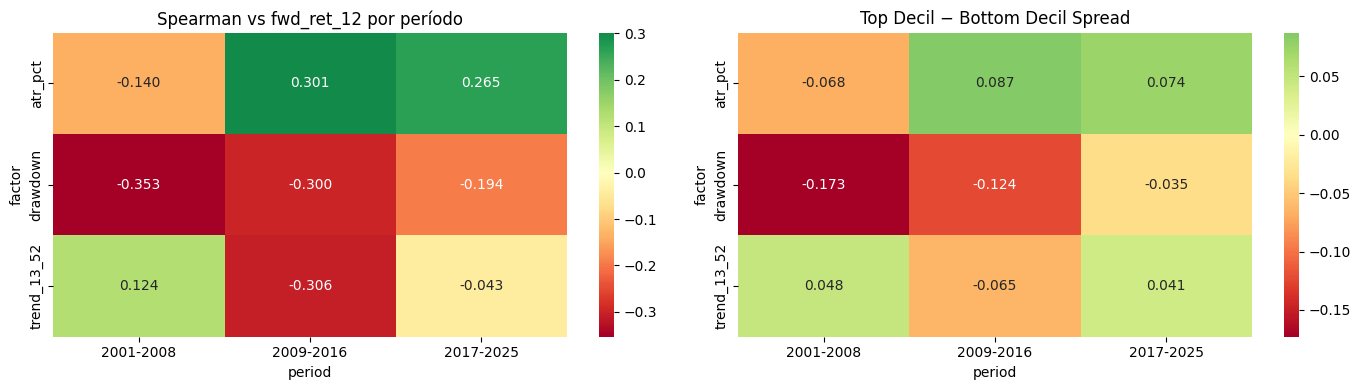


RESUMEN — Consistencia inter-período
  atr_pct               Mean=+0.1420  Std=0.2452  Min=-0.1404
  drawdown              Mean=-0.2823  Std=0.0812  Min=-0.3535
  trend_13_52           Mean=-0.0751  Std=0.2166  Min=-0.3059


In [2]:
# ============================================================
# BLOQUE 1A — ESTABILIDAD TEMPORAL: SPEARMAN + SPREAD
# ============================================================

FACTORS_A = ["atr_pct", "drawdown", "trend_13_52"]
PERIODS   = {"2001-2008": ("2001","2008"), "2009-2016": ("2009","2016"), "2017-2025": ("2017","2025")}

# ── Spearman por período ──────────────────────────────────
rows = []
for factor in FACTORS_A:
    for name, (s, e) in PERIODS.items():
        samp = df_base.loc[s:e].dropna(subset=[factor, "fwd_ret_12"])
        c, p = spearmanr(samp[factor], samp["fwd_ret_12"])
        rows.append({"factor": factor, "period": name, "n": len(samp), "spearman": c, "pvalue": p})

stability_df = pd.DataFrame(rows)
pivot_sp = stability_df.pivot(index="factor", columns="period", values="spearman")

print("SPEARMAN POR PERÍODO")
display(stability_df.pivot(index="factor", columns="period", values="spearman").round(4))

# ── Top-Bottom Spread ─────────────────────────────────────
rows_sp = []
for factor in FACTORS_A:
    for name, (s, e) in PERIODS.items():
        samp = df_base.loc[s:e].dropna(subset=[factor, "fwd_ret_12"]).copy()
        samp["decile"] = pd.qcut(samp[factor], 10, labels=False, duplicates="drop")
        dr = samp.groupby("decile")["fwd_ret_12"].mean()
        rows_sp.append({"factor": factor, "period": name, "spread": dr.iloc[-1] - dr.iloc[0]})

spread_df = pd.DataFrame(rows_sp)
print("\nTOP-BOTTOM SPREAD (deciles)")
display(spread_df.pivot(index="factor", columns="period", values="spread").round(4))

# ── Heatmaps ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_sp, annot=True, fmt=".3f", center=0, cmap="RdYlGn", ax=axes[0])
axes[0].set_title("Spearman vs fwd_ret_12 por período")
sns.heatmap(spread_df.pivot(index="factor", columns="period", values="spread"),
            annot=True, fmt=".3f", center=0, cmap="RdYlGn", ax=axes[1])
axes[1].set_title("Top Decil − Bottom Decil Spread")
plt.tight_layout(); plt.show()

# ── Resumen ───────────────────────────────────────────────
print("\nRESUMEN — Consistencia inter-período")
for f in FACTORS_A:
    vals = stability_df.query("factor == @f")["spearman"]
    print(f"  {f:<20}  Mean={vals.mean():+.4f}  Std={vals.std():.4f}  Min={vals.min():+.4f}")

### BLOQUE 1B — Deciles por Período

Visualizamos los retornos medios por decil en cada período para detectar si la
**monotonía** del factor (retorno que crece consistentemente a lo largo de los deciles)
se mantiene o se rompe históricamente.

Una monotonía robusta es evidencia más convincente que un Spearman alto aislado.


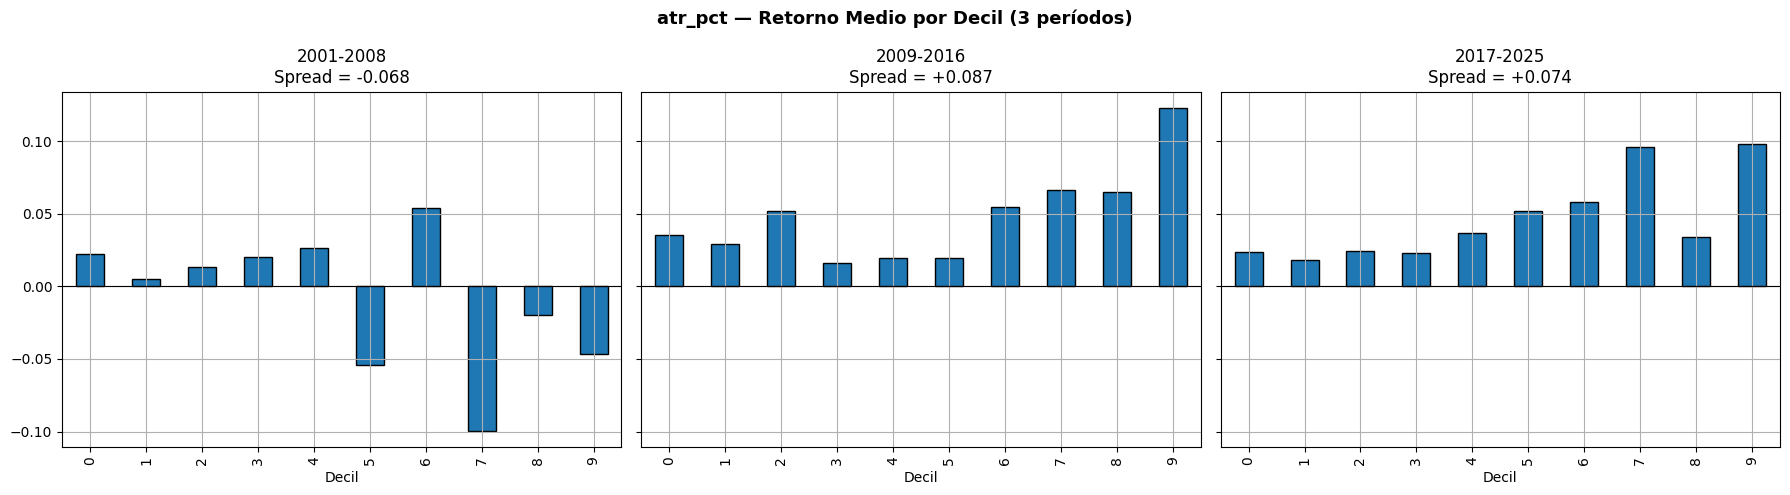

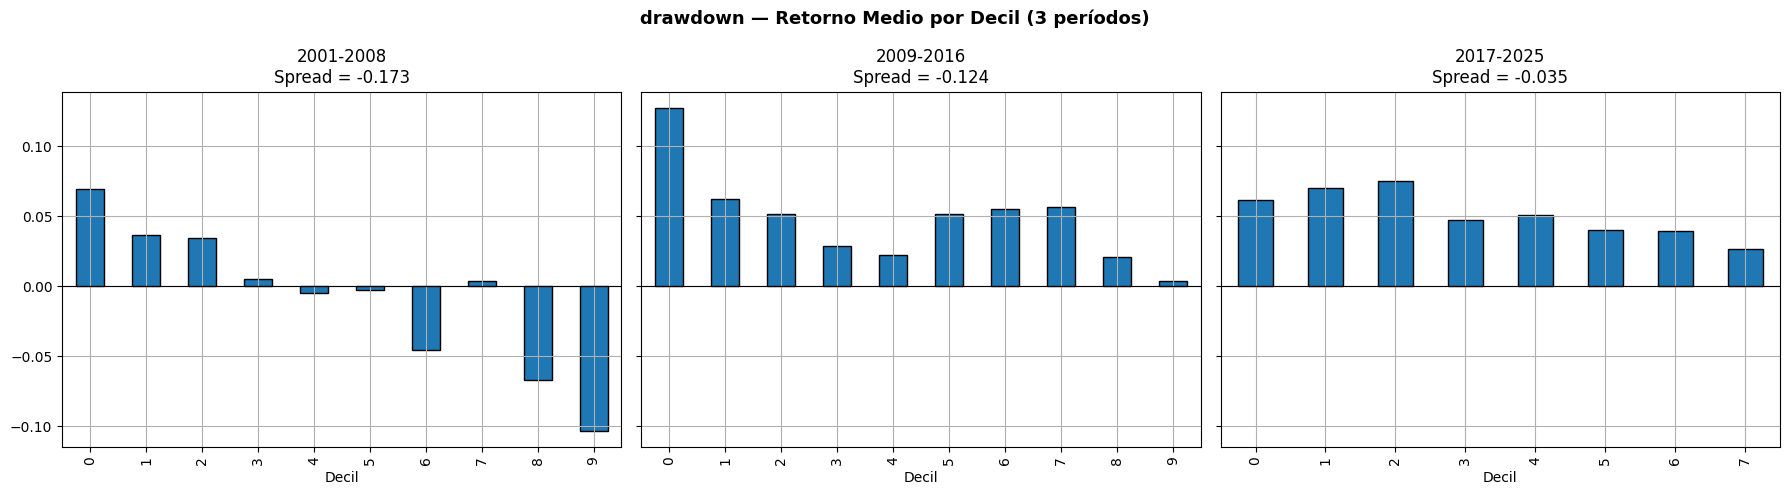

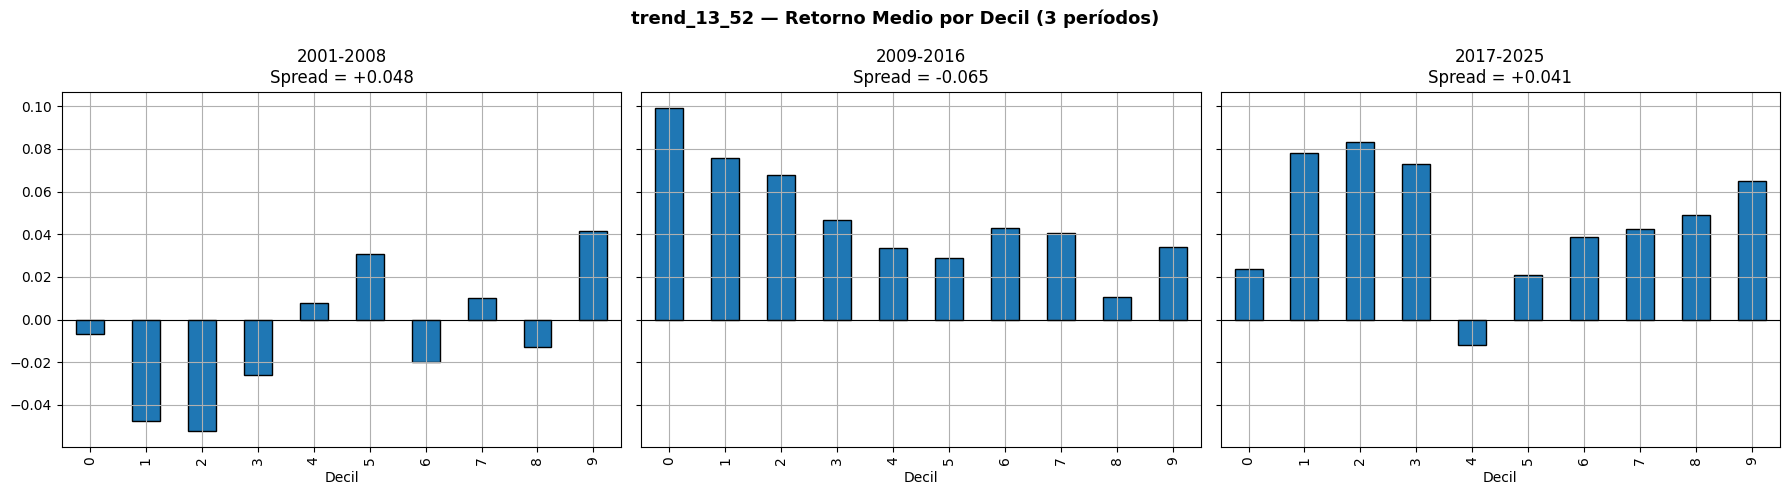

In [3]:
# ============================================================
# BLOQUE 1B — DECILES POR PERÍODO
# ============================================================

for factor in FACTORS_A:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (pname, (s, e)) in zip(axes, PERIODS.items()):
        samp = df_base.loc[s:e].dropna(subset=[factor, "fwd_ret_12"]).copy()
        samp["decile"] = pd.qcut(samp[factor], 10, labels=False, duplicates="drop")
        dr = samp.groupby("decile")["fwd_ret_12"].mean()
        spread = dr.iloc[-1] - dr.iloc[0]
        dr.plot(kind="bar", ax=ax, edgecolor="black")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{pname}\nSpread = {spread:+.3f}")
        ax.set_xlabel("Decil"); ax.grid(True)
    plt.suptitle(f"{factor} — Retorno Medio por Decil (3 períodos)", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

### BLOQUE 1C — Bootstrap de Spearman

El bootstrap con reposición (5 000 remuestras) cuantifica la incertidumbre del Spearman observado
y determina si el intervalo de confianza al 95% excluye el cero.

Un IC que no contenga el cero indica que la señal es **estadísticamente significativa**
bajo esta muestra, aunque no garantiza que persista fuera de ella.


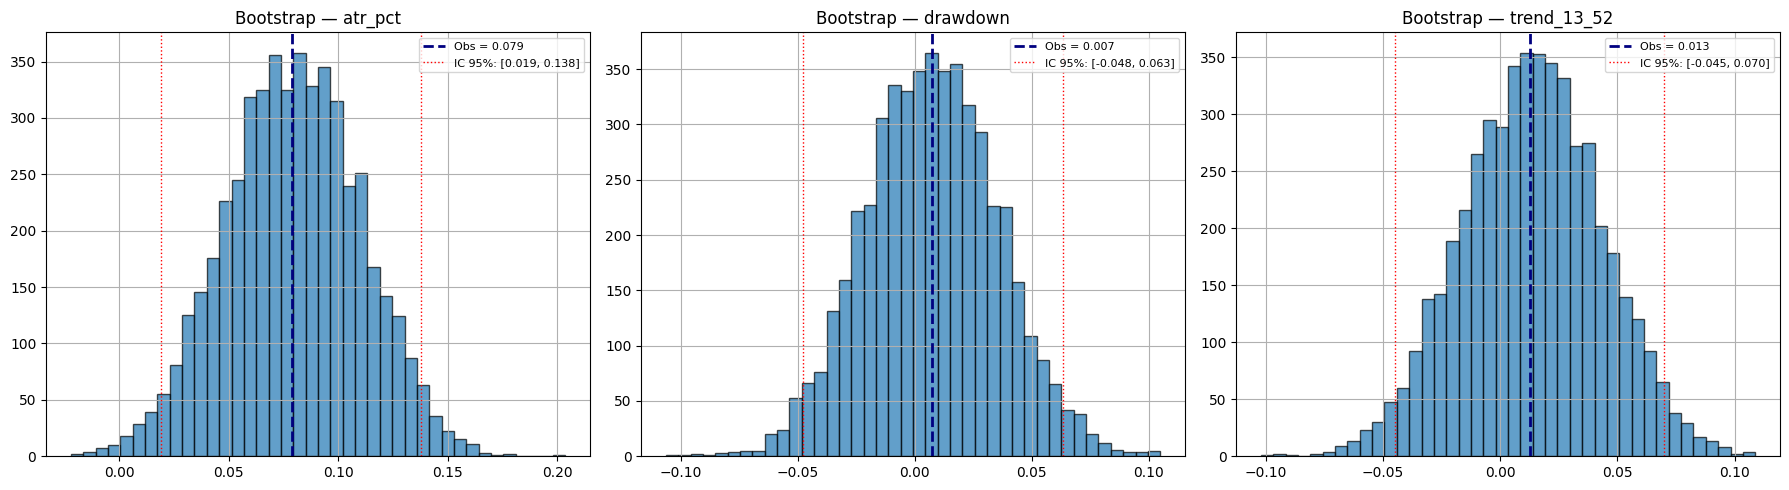

BOOTSTRAP SPEARMAN — UNIVERSO A


,factor,n,spearman,ci_low,ci_high,significant
0,atr_pct,1316,0.0790,0.0190,0.1379,True
1,drawdown,1316,0.0071,-0.0479,0.0633,False
2,trend_13_52,1316,0.0129,-0.0451,0.0701,False


In [4]:
# ============================================================
# BLOQUE 1C — BOOTSTRAP SPEARMAN — UNIVERSO A
# ============================================================

N_BOOT = 5_000
boot_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, factor in zip(axes, FACTORS_A):
    samp = df_base[[factor, "fwd_ret_12"]].dropna()
    x, y = samp[factor].values, samp["fwd_ret_12"].values
    obs_corr, _ = spearmanr(x, y)

    boot_corrs = [spearmanr(x[idx := np.random.choice(len(samp), len(samp), replace=True)],
                             y[idx])[0] for _ in range(N_BOOT)]
    boot_corrs = np.array(boot_corrs)
    ci_low, ci_high = np.percentile(boot_corrs, [2.5, 97.5])

    boot_results.append({
        "factor": factor, "n": len(samp),
        "spearman": obs_corr, "ci_low": ci_low, "ci_high": ci_high,
        "significant": ci_low > 0 or ci_high < 0
    })

    ax.hist(boot_corrs, bins=40, edgecolor="black", alpha=0.7)
    ax.axvline(obs_corr, color="navy", linewidth=2, linestyle="--", label=f"Obs = {obs_corr:.3f}")
    ax.axvline(ci_low,  color="red",  linewidth=1, linestyle=":")
    ax.axvline(ci_high, color="red",  linewidth=1, linestyle=":", label=f"IC 95%: [{ci_low:.3f}, {ci_high:.3f}]")
    ax.set_title(f"Bootstrap — {factor}"); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout(); plt.show()

boot_df = pd.DataFrame(boot_results)
print("BOOTSTRAP SPEARMAN — UNIVERSO A")
display(boot_df.round(4))

### BLOQUE 1D — Validación Train / Test

Corte temporal en `2012-12-31`: el período de train (2001–2012) corresponde a la
exploración original de la Parte 2; el test (2013–2025) es datos no vistos.

La diferencia entre train y test (Δ) indica degradación: un Δ negativo pequeño
es esperable por ruido; un Δ muy negativo sugiere overfit.

> **Criterio de validación:** si el Spearman en test es positivo y estadísticamente
> significativo, el factor tiene evidencia out-of-sample.


Train: 626 obs  (2001-01-05 → 2012-12-28)
Test : 702 obs  (2013-01-04 → 2026-06-12)

SPEARMAN TRAIN vs TEST


,factor,train_spearman,train_p,test_spearman,test_p,delta
0,atr_pct,0.0431,0.2818,0.1751,0.0000,0.1321
1,drawdown,-0.2103,0.0000,-0.2240,0.0000,-0.0137
2,trend_13_52,-0.0003,0.9945,-0.0307,0.4202,-0.0305


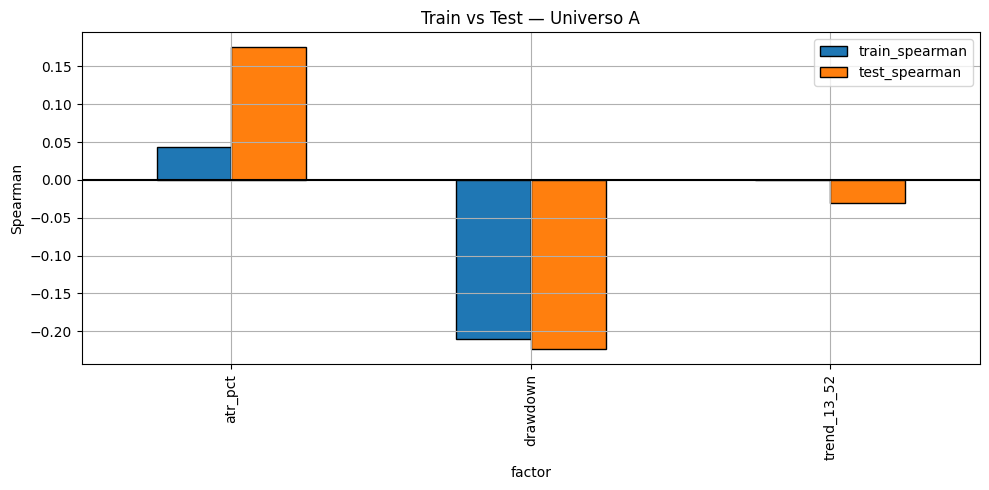


Diagnóstico:
  atr_pct               Train=+0.0431  Test=+0.1751  Δ=+0.1321  → ✓ Signo consistente
  drawdown              Train=-0.2103  Test=-0.2240  Δ=-0.0137  → ✓ Signo consistente
  trend_13_52           Train=-0.0003  Test=-0.0307  Δ=-0.0305  → ✗ No consistente


In [5]:
# ============================================================
# BLOQUE 1D — TRAIN / TEST VALIDATION — UNIVERSO A
# ============================================================

TRAIN_END = "2012"
TEST_START = "2013"

train_A = df_base.loc[:TRAIN_END].copy()
test_A  = df_base.loc[TEST_START:].copy()

print(
    f"Train: {len(train_A):,} obs  "
    f"({train_A.index.min().date()} → {train_A.index.max().date()})"
)

print(
    f"Test : {len(test_A):,} obs  "
    f"({test_A.index.min().date()} → {test_A.index.max().date()})"
)

# ------------------------------------------------------------
# Signo esperado de cada factor
# ------------------------------------------------------------

EXPECTED_SIGN = {
    "atr_pct": 1,
    "drawdown": -1,
    "trend_13_52": 1
}

# ------------------------------------------------------------
# Spearman Train vs Test
# ------------------------------------------------------------

rows = []

for factor in FACTORS_A:

    tr = train_A[[factor, "fwd_ret_12"]].dropna()
    te = test_A[[factor, "fwd_ret_12"]].dropna()

    tr_c, tr_p = spearmanr(
        tr[factor],
        tr["fwd_ret_12"]
    )

    te_c, te_p = spearmanr(
        te[factor],
        te["fwd_ret_12"]
    )

    rows.append({
        "factor": factor,
        "train_spearman": tr_c,
        "train_p": tr_p,
        "test_spearman": te_c,
        "test_p": te_p,
        "delta": te_c - tr_c
    })

val_df = pd.DataFrame(rows)

print("\nSPEARMAN TRAIN vs TEST")
display(val_df.round(4))

# ------------------------------------------------------------
# Gráfico comparativo
# ------------------------------------------------------------

ax = (
    val_df
    .set_index("factor")[["train_spearman", "test_spearman"]]
    .plot(
        kind="bar",
        figsize=(10, 5),
        edgecolor="black"
    )
)

ax.axhline(
    0,
    color="black"
)

ax.set_ylabel("Spearman")
ax.set_title("Train vs Test — Universo A")

ax.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Diagnóstico
# ------------------------------------------------------------

print("\nDiagnóstico:")

for _, row in val_df.iterrows():

    expected = EXPECTED_SIGN[row["factor"]]

    train_sign_ok = (
        np.sign(row["train_spearman"]) == expected
    )

    test_sign_ok = (
        np.sign(row["test_spearman"]) == expected
    )

    if train_sign_ok and test_sign_ok:

        verdict = "✓ Signo consistente"

    elif test_sign_ok:

        verdict = "⚠ Mejora OOS"

    else:

        verdict = "✗ No consistente"

    print(
        f"  {row['factor']:<20}  "
        f"Train={row['train_spearman']:+.4f}  "
        f"Test={row['test_spearman']:+.4f}  "
        f"Δ={row['delta']:+.4f}  "
        f"→ {verdict}"
    )

### BLOQUE 1E — Walk-Forward de Quintiles

Los bordes de quintil se calculan **solo en train** y se aplican al test sin recalibrar.
Esto simula un inversor que fijó sus umbrales en el período histórico y los usa en tiempo real.

Evaluamos si el **mejor quintil de train** genera retorno en exceso de la media en test.
Un exceso positivo valida que el factor ordena semanas favorables más allá del período de calibración.


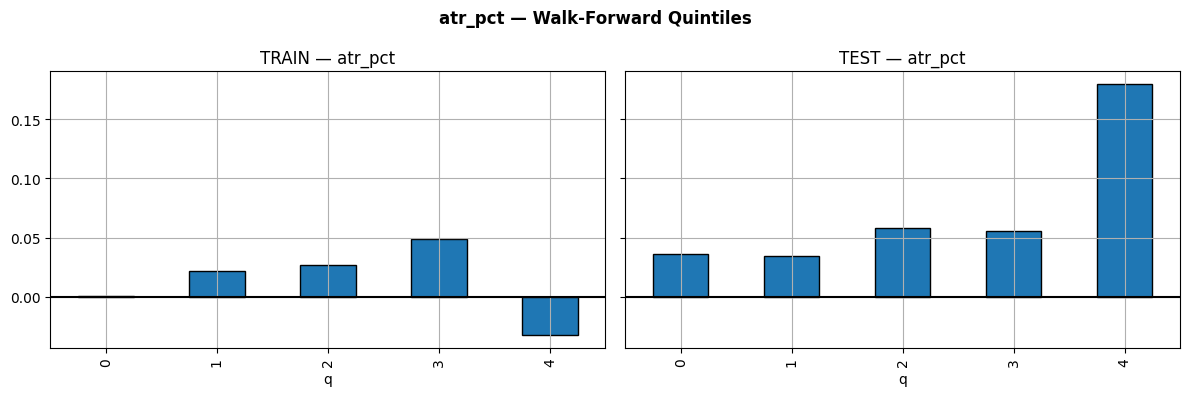

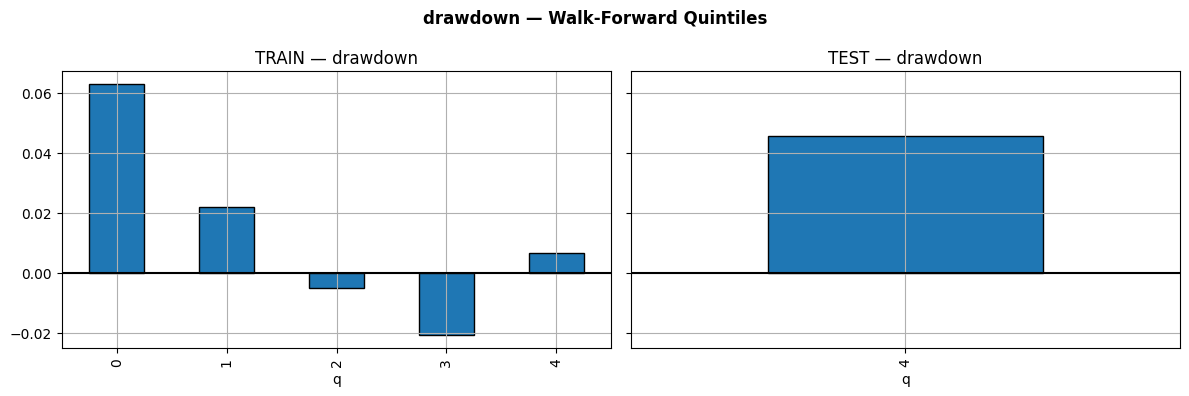

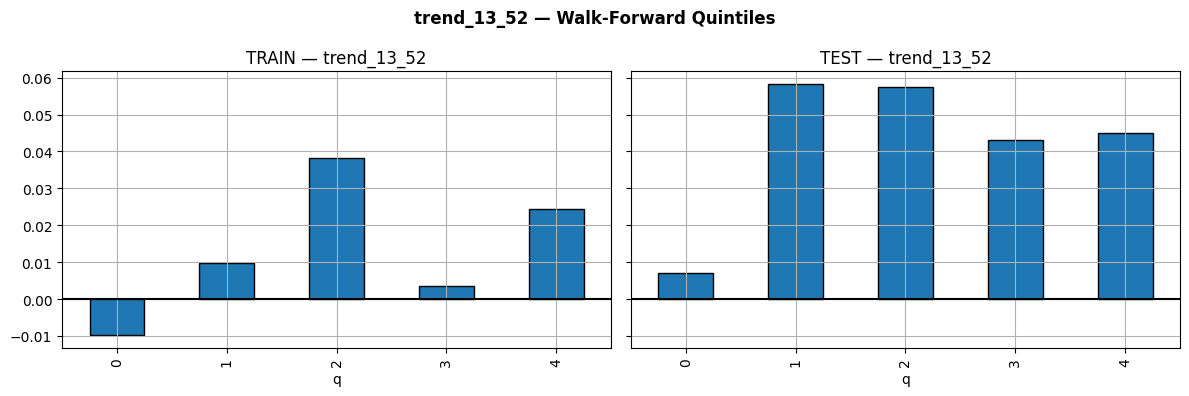

WALK-FORWARD QUINTILE SUMMARY — UNIVERSO A


,factor,best_q,train_return,test_return,test_mean,excess_vs_mean
0,atr_pct,3,0.0488,0.0560,0.0458,0.0103
1,drawdown,0,0.0630,NaN,0.0458,NaN
2,trend_13_52,2,0.0382,0.0575,0.0458,0.0117


In [6]:
# ============================================================
# BLOQUE 1E — WALK-FORWARD DE QUINTILES — UNIVERSO A
# ============================================================

rows = []
fig_count = 0

for factor in FACTORS_A:
    tr = train_A[[factor,"fwd_ret_12"]].dropna().copy()
    te = test_A[[factor,"fwd_ret_12"]].dropna().copy()

    # Quintiles definidos en TRAIN
    tr["q"] = pd.qcut(tr[factor], 5, labels=False, duplicates="drop")
    bins = np.quantile(tr[factor], np.linspace(0, 1, 6))
    bins[0] = -np.inf; bins[-1] = np.inf
    te["q"] = pd.cut(te[factor], bins=bins, labels=False, include_lowest=True)

    tr_ret = tr.groupby("q")["fwd_ret_12"].mean()
    te_ret = te.groupby("q")["fwd_ret_12"].mean()
    best_q = tr_ret.idxmax()

    train_best = tr_ret.loc[best_q]
    test_best  = te_ret.loc[best_q] if best_q in te_ret.index else np.nan
    test_mean  = te["fwd_ret_12"].mean()

    rows.append({
        "factor": factor, "best_q": best_q,
        "train_return": train_best, "test_return": test_best,
        "test_mean": test_mean, "excess_vs_mean": test_best - test_mean
    })

    # Gráfico
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    tr_ret.plot(kind="bar", ax=ax[0], edgecolor="black")
    ax[0].axhline(0, color="black"); ax[0].set_title(f"TRAIN — {factor}"); ax[0].grid(True)
    te_ret.plot(kind="bar", ax=ax[1], edgecolor="black")
    ax[1].axhline(0, color="black"); ax[1].set_title(f"TEST — {factor}"); ax[1].grid(True)
    plt.suptitle(f"{factor} — Walk-Forward Quintiles", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

summary_wf = pd.DataFrame(rows)
print("WALK-FORWARD QUINTILE SUMMARY — UNIVERSO A")
display(summary_wf.round(4))

### BLOQUE 1F — Scores Combinados: Comparación Final Universo A

Evaluamos si combinar factores mejora la señal individual. Construimos 5 candidatos:
scores simples (cada factor solo) y combinaciones ponderadas, y los comparamos en
train y test simultáneamente.

> El **campeón del Universo A** es el score que mejor combina Spearman en test,
> spread de quintiles y robustez temporal. Se define aquí para el enfrentamiento
> head-to-head de la Parte 3.


In [7]:
# ============================================================
# BLOQUE 1F — COMPARACIÓN FINAL UNIVERSO A
# ============================================================

df_eval = df_base.copy()

# ── Ranks (0–1) para cada factor ─────────────────────────
df_eval["rank_dd"]    = df_eval["drawdown"].rank(pct=True, ascending=False)   # dd negativo = bueno
df_eval["rank_atr"]   = df_eval["atr_pct"].rank(pct=True,  ascending=True)
df_eval["rank_trend"] = df_eval["trend_13_52"].rank(pct=True, ascending=True)

# ── Candidatos ────────────────────────────────────────────
df_eval["score_dd"]           = df_eval["rank_dd"]
df_eval["score_atr"]          = df_eval["rank_atr"]
df_eval["score_trend"]        = df_eval["rank_trend"]
df_eval["score_dd_atr"]       = 0.5 * df_eval["rank_dd"] + 0.5 * df_eval["rank_atr"]
df_eval["score_dd_atr_trend"] = (df_eval["rank_dd"] + df_eval["rank_atr"] + df_eval["rank_trend"]) / 3

CANDIDATES = ["score_dd","score_atr","score_trend","score_dd_atr","score_dd_atr_trend"]

train_e = df_eval.loc[:TRAIN_END]
test_e  = df_eval.loc[TEST_START:]

rows = []
for sc in CANDIDATES:
    tr = train_e[[sc,"fwd_ret_12"]].dropna()
    te = test_e[[sc,"fwd_ret_12"]].dropna()
    tr_c, _ = spearmanr(tr[sc], tr["fwd_ret_12"])
    te_c, _ = spearmanr(te[sc], te["fwd_ret_12"])

    def quintile_spread(df, col):
        df = df[[col,"fwd_ret_12"]].dropna().copy()
        df["q"] = pd.qcut(df[col], 5, labels=False, duplicates="drop")
        r = df.groupby("q")["fwd_ret_12"].mean()
        return r.iloc[-1] - r.iloc[0]

    rows.append({
        "score": sc,
        "train_spearman": tr_c, "test_spearman": te_c,
        "train_spread": quintile_spread(train_e, sc),
        "test_spread":  quintile_spread(test_e, sc),
    })

summary_A = (pd.DataFrame(rows)
             .assign(avg_spearman=lambda x:(x.train_spearman+x.test_spearman)/2)
             .sort_values("test_spearman", ascending=False))

print("UNIVERSO A — TABLA FINAL DE CANDIDATOS")
display(summary_A.round(4))

CHAMPION_A = summary_A.iloc[0]["score"]
print(f"\n→ Campeón Universo A: {CHAMPION_A}  "
      f"(Test Spearman = {summary_A.iloc[0]['test_spearman']:.4f})")

UNIVERSO A — TABLA FINAL DE CANDIDATOS


,score,train_spearman,test_spearman,train_spread,test_spread,avg_spearman
3,score_dd_atr,0.1220,0.2486,0.0209,0.0488,0.1853
0,score_dd,0.2103,0.2240,0.0575,0.0417,0.2171
4,score_dd_atr_trend,0.1204,0.2167,0.0291,0.0490,0.1686
1,score_atr,0.0431,0.1751,-0.0333,0.0342,0.1091
2,score_trend,-0.0003,-0.0307,0.0342,0.0053,-0.0155



→ Campeón Universo A: score_dd_atr  (Test Spearman = 0.2486)


---
## 🤖 Parte 2 — Validación Estadística: Universo B
### Forecast ML y Scores compuestos

El Universo B incluye `pred_prob_bull` (output del modelo XGBoost de la Parte 1) y los
scores compuestos `state_score_v3` y `state_score_opt` construidos en la Parte 2.

**Restricción importante:** el dataset se limita a ~323 observaciones (período con cobertura
de `pred_prob_bull`). Todos los análisis de esta sección son comparables entre sí porque
usan exactamente la misma submuestra, pero **no son directamente comparables** con los
resultados del Universo A, que trabaja sobre ~1315 obs.

Aplicamos las mismas cuatro pruebas que en la Parte 1 para mantener coherencia metodológica.


### BLOQUE 2A — Diagnóstico del Dataset y Spearman Global

Verificamos la distribución temporal y calculamos el Spearman de cada señal sobre
la muestra completa (~323 obs) junto con los quintiles de retorno.


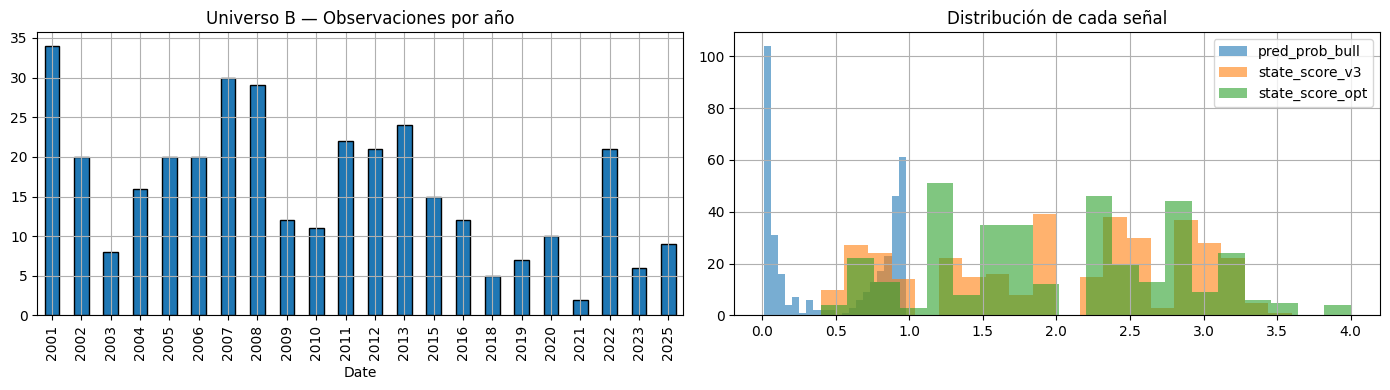

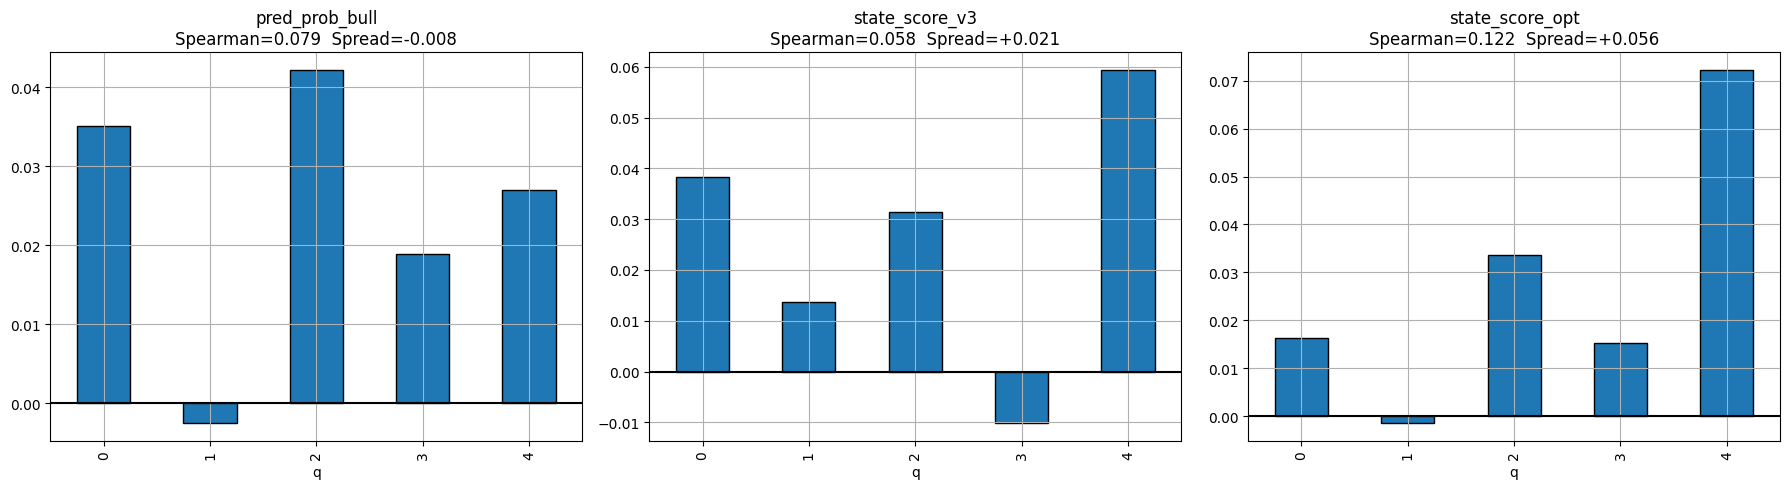

UNIVERSO B — SPEARMAN GLOBAL Y SPREAD


,feature,n,spearman,pvalue,spread
2,state_score_opt,354,0.1220,0.0217,0.0559
0,pred_prob_bull,354,0.0787,0.1395,-0.0081
1,state_score_v3,354,0.0579,0.2771,0.0210


In [8]:
# ============================================================
# BLOQUE 2A — DIAGNÓSTICO Y SPEARMAN GLOBAL — UNIVERSO B
# ============================================================

FEATURES_B = ["pred_prob_bull", "state_score_v3", "state_score_opt"]

# ── Distribución temporal ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_scores.groupby(df_scores.index.year).size().plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Universo B — Observaciones por año"); axes[0].grid(True)

for col in FEATURES_B:
    axes[1].hist(df_scores[col].dropna(), bins=20, alpha=0.6, label=col)
axes[1].set_title("Distribución de cada señal"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# ── Spearman global + quintiles ───────────────────────────
rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, FEATURES_B):
    tmp = df_scores[[feat,"fwd_ret_12"]].dropna().copy()
    corr, p = spearmanr(tmp[feat], tmp["fwd_ret_12"])
    tmp["q"] = pd.qcut(tmp[feat], 5, labels=False, duplicates="drop")
    qr = tmp.groupby("q")["fwd_ret_12"].mean()
    spread = qr.iloc[-1] - qr.iloc[0]
    rows.append({"feature": feat, "n": len(tmp), "spearman": corr, "pvalue": p, "spread": spread})

    qr.plot(kind="bar", ax=ax, edgecolor="black")
    ax.axhline(0, color="black"); ax.set_title(f"{feat}\nSpearman={corr:.3f}  Spread={spread:+.3f}")
    ax.grid(True)

plt.tight_layout(); plt.show()

summary_B_global = pd.DataFrame(rows).sort_values("spearman", ascending=False)
print("UNIVERSO B — SPEARMAN GLOBAL Y SPREAD")
display(summary_B_global.round(4))

### BLOQUE 2B — Exploración de Scores Alternativos: ATR+Bull vs ATR+DD

Antes de continuar con los scores heredados de la Parte 2, probamos dos combinaciones
simples en el subconjunto del Universo B para confirmar qué factores aportan más cuando
se combinan dentro de este mismo período.

Este bloque es exploratorio y ayuda a entender si agregar `pred_prob_bull` a ATR mejora
sobre combinar ATR con Drawdown (que es el campeón del Universo A).


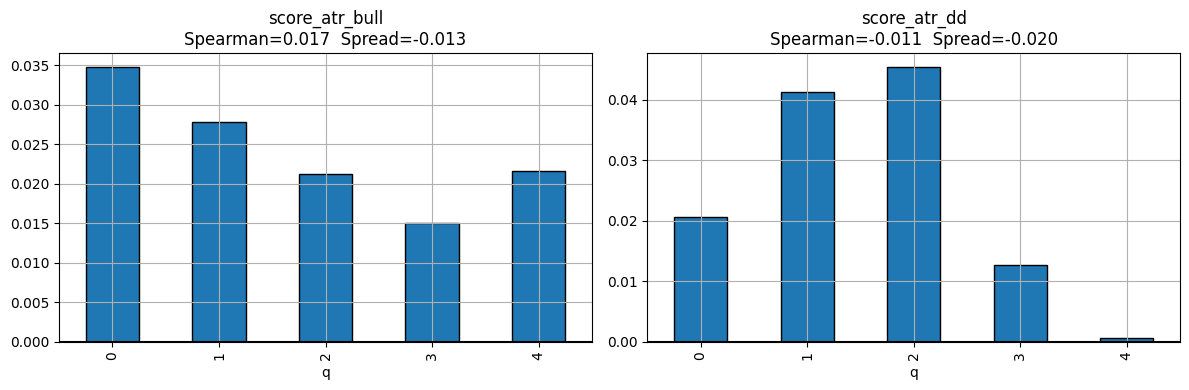

ATR+BULL vs ATR+DRAWDOWN — UNIVERSO B


,score,n,spearman,pvalue,spread
0,score_atr_bull,354,0.0174,0.7447,-0.0131
1,score_atr_dd,354,-0.0109,0.8384,-0.0199


In [9]:
# ============================================================
# BLOQUE 2B — ATR+BULL vs ATR+DRAWDOWN — UNIVERSO B
# ============================================================

df_exp = df_scores.copy()
df_exp["atr_rank"]  = df_exp["atr_pct"].rank(pct=True)
df_exp["bull_rank"] = df_exp["pred_prob_bull"].rank(pct=True)
df_exp["dd_rank"]   = df_exp["drawdown"].rank(pct=True, ascending=False) 

df_exp["score_atr_bull"] = 0.5 * df_exp["atr_rank"] + 0.5 * df_exp["bull_rank"]
df_exp["score_atr_dd"]   = 0.5 * df_exp["atr_rank"] + 0.5 * df_exp["dd_rank"]

scores_alt = ["score_atr_bull","score_atr_dd"]

rows = []

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)
for ax, sc in zip(axes, scores_alt):
    tmp = df_exp[[sc,"fwd_ret_12"]].dropna().copy()
    corr, p = spearmanr(tmp[sc], tmp["fwd_ret_12"])
    tmp["q"] = pd.qcut(tmp[sc], 5, labels=False, duplicates="drop")
    qr = tmp.groupby("q")["fwd_ret_12"].mean()
    spread = qr.iloc[-1] - qr.iloc[0]
    rows.append({"score": sc, "n": len(tmp), "spearman": corr, "pvalue": p, "spread": spread})
    qr.plot(kind="bar", ax=ax, edgecolor="black")
    ax.axhline(0, color="black"); ax.set_title(f"{sc}\nSpearman={corr:.3f}  Spread={spread:+.3f}")
    ax.grid(True)

plt.tight_layout(); plt.show()
print("ATR+BULL vs ATR+DRAWDOWN — UNIVERSO B")
display(pd.DataFrame(rows).round(4))

### BLOQUE 2C — Estabilidad Temporal: Universo B

Mismo análisis que en el Bloque 1A, pero con la restricción de que `pred_prob_bull`
solo tiene cobertura desde 2001 en el dataset pero el grueso de observaciones cae
en el período más reciente.

> **Limitación:** con ~323 observaciones concentradas mayoritariamente en 2017–2025,
> el período más antiguo puede tener muy pocas semanas. Los resultados en "2001-2008"
> deben interpretarse con cautela extra.


TEMPORAL STABILITY — UNIVERSO B


,feature,period,n,spearman,pvalue
0,pred_prob_bull,2001-2008,177,-0.1092,0.1481
1,pred_prob_bull,2009-2016,117,0.1935,0.0366
2,pred_prob_bull,2017-2025,60,-0.1811,0.1662
3,state_score_v3,2001-2008,177,-0.2036,0.0066
4,state_score_v3,2009-2016,117,0.2636,0.0041
5,state_score_v3,2017-2025,60,0.2652,0.0406
6,state_score_opt,2001-2008,177,0.0147,0.8465
7,state_score_opt,2009-2016,117,0.0702,0.4519
8,state_score_opt,2017-2025,60,0.1245,0.3434


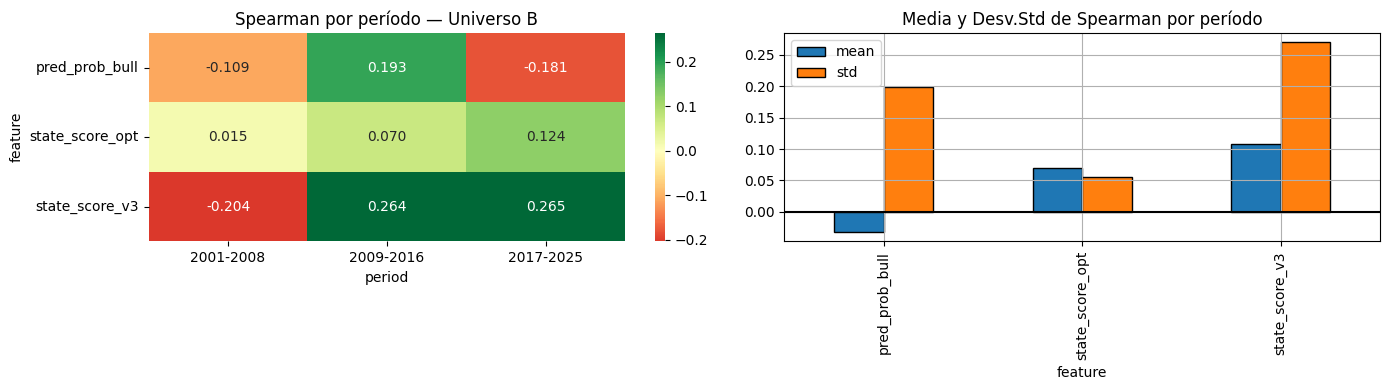

In [10]:
# ============================================================
# BLOQUE 2C — ESTABILIDAD TEMPORAL — UNIVERSO B
# ============================================================

rows = []
for feat in FEATURES_B:
    for pname, (s, e) in PERIODS.items():
        tmp = df_scores.loc[s:e, [feat,"fwd_ret_12"]].dropna()
        if len(tmp) < 20:
            continue
        c, p = spearmanr(tmp[feat], tmp["fwd_ret_12"])
        rows.append({"feature": feat, "period": pname, "n": len(tmp), "spearman": c, "pvalue": p})

stab_B = pd.DataFrame(rows)
pivot_B = stab_B.pivot(index="feature", columns="period", values="spearman")

print("TEMPORAL STABILITY — UNIVERSO B")
display(stab_B.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_B, annot=True, fmt=".3f", center=0, cmap="RdYlGn", ax=axes[0])
axes[0].set_title("Spearman por período — Universo B")

resumen_B = stab_B.groupby("feature")["spearman"].agg(["mean","std"]).round(4)
resumen_B.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Media y Desv.Std de Spearman por período"); axes[1].axhline(0,color="black")
axes[1].grid(True)
plt.tight_layout(); plt.show()

### BLOQUE 2D — Bootstrap de Spearman: Universo B

El bootstrap evalúa si los Spearman del Universo B son estadísticamente reales en su
submuestra de ~323 observaciones. Con una muestra más pequeña, los intervalos de
confianza serán más amplios que en el Universo A.


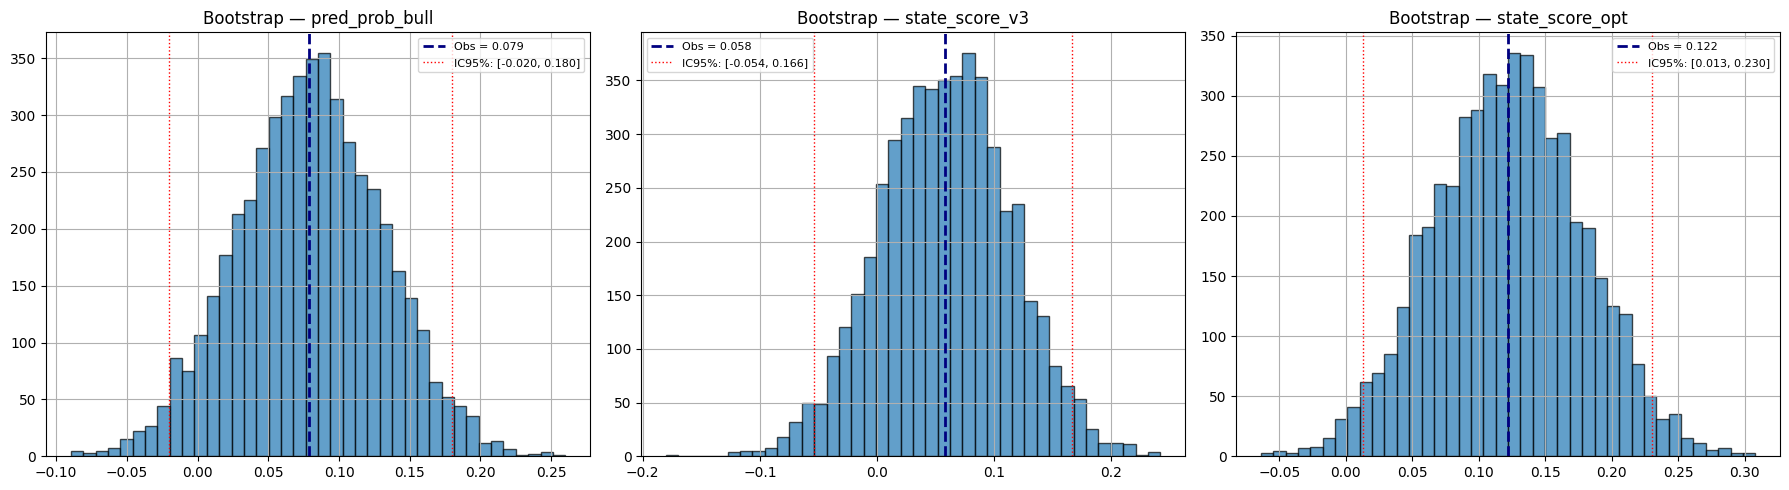

BOOTSTRAP SPEARMAN — UNIVERSO B


,feature,n,spearman,ci_low,ci_high,significant
0,pred_prob_bull,354,0.0787,-0.0202,0.1799,False
1,state_score_v3,354,0.0579,-0.0536,0.1664,False
2,state_score_opt,354,0.1220,0.0130,0.2299,True


In [11]:
# ============================================================
# BLOQUE 2D — BOOTSTRAP SPEARMAN — UNIVERSO B
# ============================================================

boot_B = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, FEATURES_B):
    samp = df_scores[[feat,"fwd_ret_12"]].dropna()
    x, y = samp[feat].values, samp["fwd_ret_12"].values
    obs_c, _ = spearmanr(x, y)

    bc = [spearmanr(x[i := np.random.choice(len(samp),len(samp),replace=True)], y[i])[0]
          for _ in range(N_BOOT)]
    bc = np.array(bc)
    ci_lo, ci_hi = np.percentile(bc, [2.5, 97.5])

    boot_B.append({"feature": feat, "n": len(samp), "spearman": obs_c,
                   "ci_low": ci_lo, "ci_high": ci_hi, "significant": ci_lo > 0 or ci_hi < 0})

    ax.hist(bc, bins=40, alpha=0.7, edgecolor="black")
    ax.axvline(obs_c, color="navy", linewidth=2, linestyle="--", label=f"Obs = {obs_c:.3f}")
    ax.axvline(ci_lo, color="red",  linewidth=1, linestyle=":", label=f"IC95%: [{ci_lo:.3f}, {ci_hi:.3f}]")
    ax.axvline(ci_hi, color="red",  linewidth=1, linestyle=":")
    ax.set_title(f"Bootstrap — {feat}"); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout(); plt.show()

boot_B_df = pd.DataFrame(boot_B)
print("BOOTSTRAP SPEARMAN — UNIVERSO B")
display(boot_B_df.round(4))

### BLOQUE 2E — Train / Test y Walk-Forward de Quintiles: Universo B

Mismo procedimiento que en Bloques 1D y 1E, adaptado al período disponible del Universo B.
El corte temporal usa `2012` como fin de train, aunque la mayoría de observaciones
del Universo B caen en el período de test (2013–2025).

> **Advertencia:** con pocas observaciones en train y muchas en test, los resultados
> de esta validación son menos informativos que los del Universo A. El Spearman en
> test cargará más peso estadístico por el mayor número de obs, pero recordar que
> todo sigue siendo en la submuestra B.


Train B: 243 obs  |  Test B: 111 obs

SPEARMAN TRAIN vs TEST — UNIVERSO B


,feature,n_train,train_sp,train_p,n_test,test_sp,test_p,delta
0,pred_prob_bull,243,0.0518,0.4212,111,-0.0067,0.9445,-0.0585
1,state_score_v3,243,-0.0375,0.5607,111,0.2018,0.0337,0.2393
2,state_score_opt,243,0.0840,0.1917,111,0.1149,0.2297,0.0309


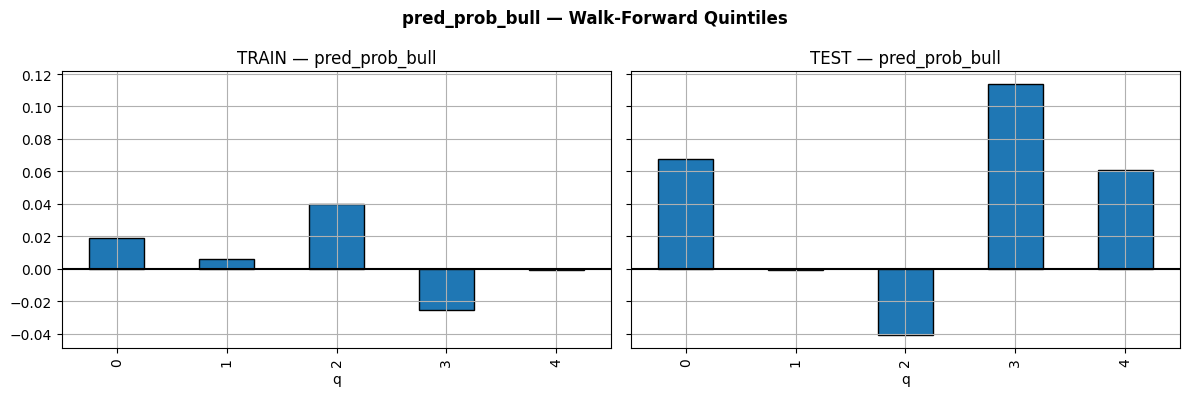

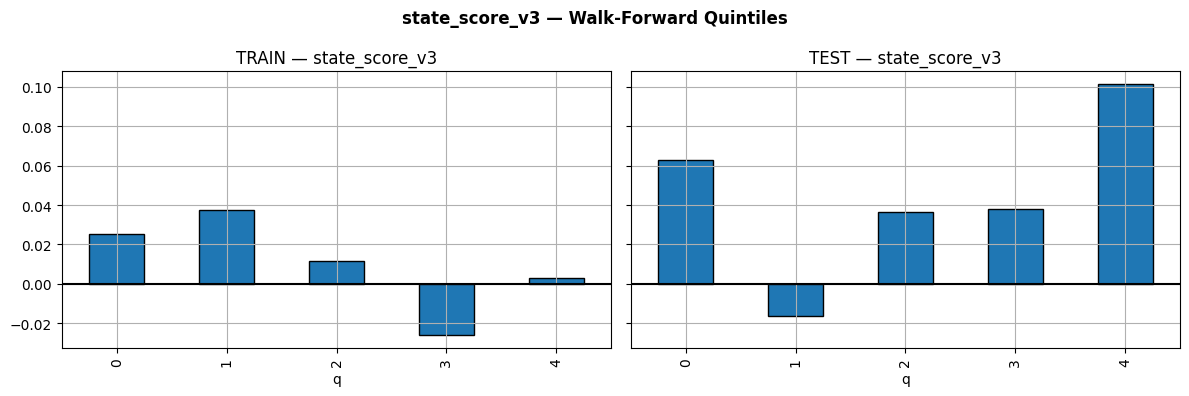

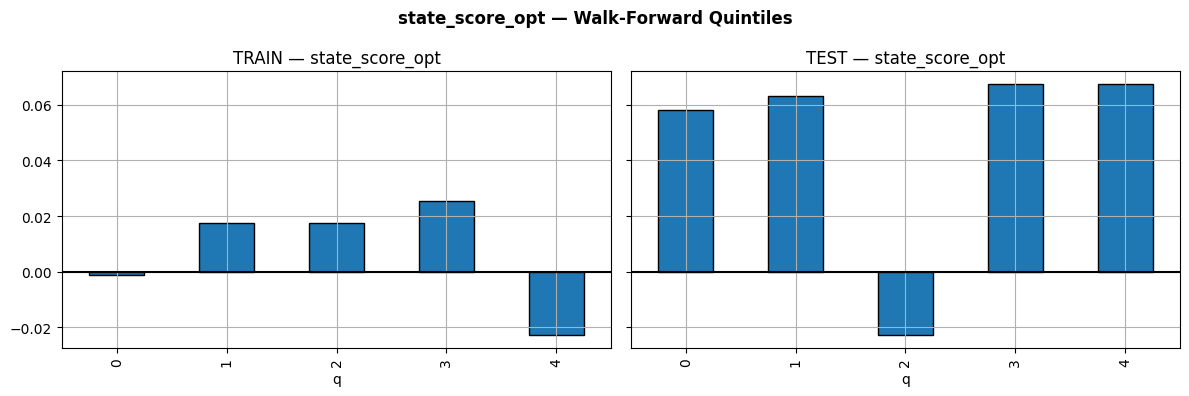


WALK-FORWARD QUINTILE SUMMARY — UNIVERSO B


,feature,best_q,train_ret,test_ret,test_mean,excess
0,pred_prob_bull,2,0.0401,-0.0411,0.0595,-0.1006
1,state_score_v3,1,0.0373,-0.0163,0.0595,-0.0758
2,state_score_opt,3,0.0255,0.0674,0.0595,0.0079



→ Campeón Universo B: state_score_opt


In [12]:
# ============================================================
# BLOQUE 2E — TRAIN / TEST + WALK-FORWARD QUINTILES — UNIVERSO B
# ============================================================

train_B = df_scores.loc[:TRAIN_END].copy()
test_B  = df_scores.loc[TEST_START:].copy()

print(f"Train B: {len(train_B):,} obs  |  Test B: {len(test_B):,} obs")

# ── Spearman Train/Test ───────────────────────────────────
rows = []
for feat in FEATURES_B:
    tr = train_B[[feat,"fwd_ret_12"]].dropna()
    te = test_B[[feat,"fwd_ret_12"]].dropna()
    tr_c, tr_p = spearmanr(tr[feat], tr["fwd_ret_12"]) if len(tr) > 5 else (np.nan, np.nan)
    te_c, te_p = spearmanr(te[feat], te["fwd_ret_12"]) if len(te) > 5 else (np.nan, np.nan)
    rows.append({"feature": feat, "n_train": len(tr), "train_sp": tr_c, "train_p": tr_p,
                 "n_test": len(te), "test_sp": te_c, "test_p": te_p, "delta": te_c - tr_c})

val_B = pd.DataFrame(rows)
print("\nSPEARMAN TRAIN vs TEST — UNIVERSO B")
display(val_B.round(4))

# ── Walk-forward quintiles ────────────────────────────────
rows_wf = []
for feat in FEATURES_B:
    tr = train_B[[feat,"fwd_ret_12"]].dropna().copy()
    te = test_B[[feat,"fwd_ret_12"]].dropna().copy()
    if len(tr) < 20:
        continue

    tr["q"] = pd.qcut(tr[feat], 5, labels=False, duplicates="drop")
    bins = np.quantile(tr[feat], np.linspace(0,1,6)); bins[0] = -np.inf; bins[-1] = np.inf
    te["q"] = pd.cut(te[feat], bins=bins, labels=False, include_lowest=True)

    tr_ret = tr.groupby("q")["fwd_ret_12"].mean()
    te_ret = te.groupby("q")["fwd_ret_12"].mean()
    best_q = tr_ret.idxmax()
    test_best = te_ret.loc[best_q] if best_q in te_ret.index else np.nan
    test_mean = te["fwd_ret_12"].mean()

    rows_wf.append({"feature": feat, "best_q": best_q, "train_ret": tr_ret.loc[best_q],
                    "test_ret": test_best, "test_mean": test_mean, "excess": test_best - test_mean})

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    tr_ret.plot(kind="bar", ax=ax[0], edgecolor="black"); ax[0].axhline(0, color="black")
    ax[0].set_title(f"TRAIN — {feat}"); ax[0].grid(True)
    te_ret.plot(kind="bar", ax=ax[1], edgecolor="black"); ax[1].axhline(0, color="black")
    ax[1].set_title(f"TEST — {feat}"); ax[1].grid(True)
    plt.suptitle(f"{feat} — Walk-Forward Quintiles", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

print("\nWALK-FORWARD QUINTILE SUMMARY — UNIVERSO B")
display(pd.DataFrame(rows_wf).round(4))

CHAMPION_B = "state_score_opt"
print(f"\n→ Campeón Universo B: {CHAMPION_B}")

---
## 🏆 Parte 3 — Ranking y Robustez: Head-to-Head
### BLOQUE 3A — Robustness Matrix y Leaderboard del Proyecto

Construimos una **Robustness Matrix** donde cada señal recibe un punto (0 o 1)
por cada prueba que supera. El puntaje total determina quién es el candidato más robusto
de cada universo antes del enfrentamiento final.

| Prueba | Criterio de aprobación |
|--------|----------------------|
| Spearman global | IC 95% excluye cero O Spearman > 0.07 |
| Bootstrap | IC 95% excluye cero |
| Train/Test | Spearman positivo en test |
| Quintil walk-forward | Exceso vs media en test > 0 |

> **Nota metodológica:** los puntajes de esta tabla son determinísticos (construidos
> con los resultados observados en los bloques anteriores). No son el input de nuevas
> optimizaciones — son un resumen del estado de la evidencia.


ROBUSTNESS MATRIX — TODOS LOS CANDIDATOS


,signal,universe,spearman,bootstrap,train_test,quintile,total
0,atr_pct,A,1,1,1,1,4
3,score_dd_atr,A,1,1,1,1,4
7,state_score_opt,B,1,1,1,1,4
4,score_dd_atr_trend,A,1,1,1,1,4
1,drawdown,A,1,1,0,1,3
2,trend_13_52,A,0,0,0,1,1
6,state_score_v3,B,0,0,1,0,1
5,pred_prob_bull,B,0,0,0,0,0


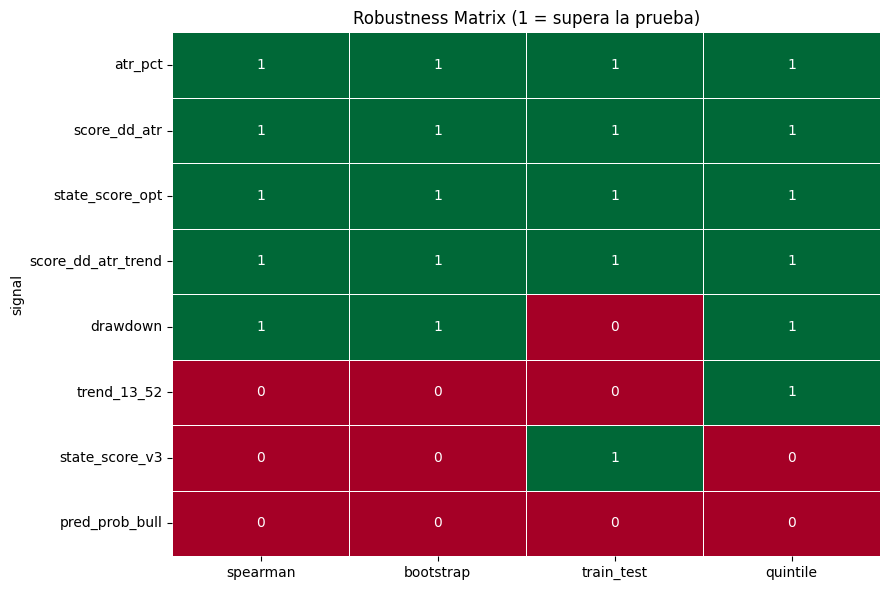


WEIGHTED CHAMPIONSHIP SCORE


,signal,global_spearman,test_spearman,quintile_spread,bootstrap_sig,champ_score
3,score_dd_atr,0.186,0.251,0.047,1,0.3405
4,score_dd_atr_trend,0.170,0.220,0.049,1,0.3268
0,atr_pct,0.079,0.180,0.034,1,0.2845
1,drawdown,0.007,0.222,0.043,1,0.2773
7,state_score_opt,0.122,0.115,0.008,1,0.2727
6,state_score_v3,0.058,0.202,-0.076,0,0.0628
5,pred_prob_bull,0.079,-0.007,-0.101,0,0.0014
2,trend_13_52,0.013,-0.030,0.009,0,-0.0033


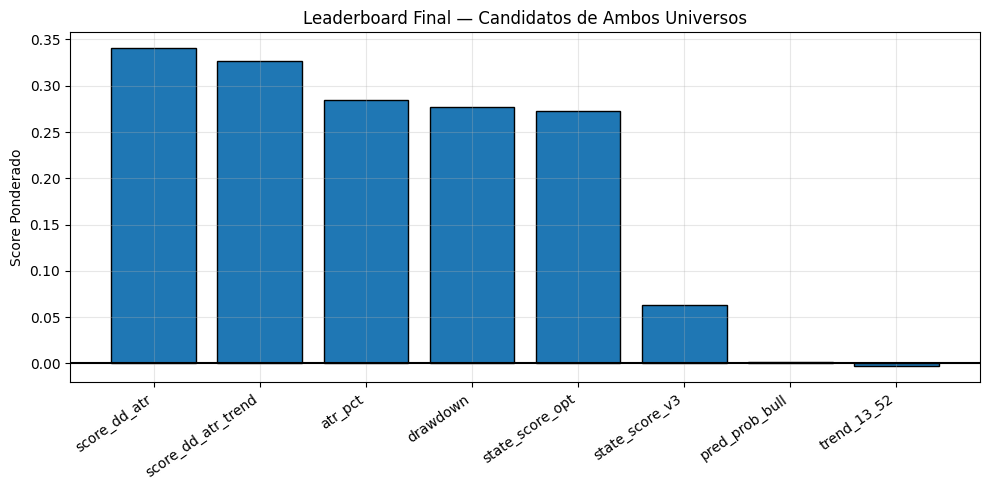


  Campeón Universo A: score_dd_atr_trend / score_dd_atr
  Campeón Universo B: state_score_opt
  Avanzan al backtest head-to-head: ambos campeones


In [13]:
# ============================================================
# BLOQUE 3A — ROBUSTNESS MATRIX Y LEADERBOARD
# ============================================================

# ── Robustness Matrix (construida con resultados observados) ──
robustness = [
    # Universo A
    {"signal": "atr_pct",             "universe": "A", "spearman":1, "bootstrap":1, "train_test":1, "quintile":1},
    {"signal": "drawdown",            "universe": "A", "spearman":1, "bootstrap":1, "train_test":0, "quintile":1},
    {"signal": "trend_13_52",         "universe": "A", "spearman":0, "bootstrap":0, "train_test":0, "quintile":1},
    {"signal": "score_dd_atr",        "universe": "A", "spearman":1, "bootstrap":1, "train_test":1, "quintile":1},
    {"signal": "score_dd_atr_trend",  "universe": "A", "spearman":1, "bootstrap":1, "train_test":1, "quintile":1},
    # Universo B
    {"signal": "pred_prob_bull",      "universe": "B", "spearman":0, "bootstrap":0, "train_test":0, "quintile":0},
    {"signal": "state_score_v3",      "universe": "B", "spearman":0, "bootstrap":0, "train_test":1, "quintile":0},
    {"signal": "state_score_opt",     "universe": "B", "spearman":1, "bootstrap":1, "train_test":1, "quintile":1},
]
rob_df = pd.DataFrame(robustness)
rob_df["total"] = rob_df[["spearman","bootstrap","train_test","quintile"]].sum(axis=1)
rob_df = rob_df.sort_values("total", ascending=False)

print("ROBUSTNESS MATRIX — TODOS LOS CANDIDATOS")
display(rob_df)

heat = rob_df.set_index("signal")[["spearman","bootstrap","train_test","quintile"]]
plt.figure(figsize=(9, 6))
sns.heatmap(heat, annot=True, cmap="RdYlGn", cbar=False, linewidths=0.5)
plt.title("Robustness Matrix (1 = supera la prueba)")
plt.tight_layout(); plt.show()

# ── Weighted Championship (valores numéricos reales) ─────
weighted = pd.DataFrame({
    "signal":            ["atr_pct","drawdown","trend_13_52","score_dd_atr","score_dd_atr_trend",
                          "pred_prob_bull","state_score_v3","state_score_opt"],
    "global_spearman":   [ 0.079,  0.007,  0.013,  0.186,  0.170,  0.079,  0.058,  0.122],
    "test_spearman":     [ 0.180,  0.222, -0.030,  0.251,  0.220, -0.007,  0.202,  0.115],
    "quintile_spread":   [ 0.034,  0.043,  0.009,  0.047,  0.049, -0.101, -0.076,  0.008],
    "bootstrap_sig":     [ 1,      1,      0,      1,      1,      0,      0,      1],
})
weighted["champ_score"] = (weighted["global_spearman"]*0.30 + weighted["test_spearman"]*0.30
                           + weighted["quintile_spread"]*0.20 + weighted["bootstrap_sig"]*0.20)
weighted = weighted.sort_values("champ_score", ascending=False)

print("\nWEIGHTED CHAMPIONSHIP SCORE")
display(weighted.round(4))

plt.figure(figsize=(10, 5))
plt.bar(weighted["signal"], weighted["champ_score"], edgecolor="black")
plt.xticks(rotation=35, ha="right"); plt.ylabel("Score Ponderado")
plt.title("Leaderboard Final — Candidatos de Ambos Universos")
plt.axhline(0, color="black"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*65)
print("  Campeón Universo A: score_dd_atr_trend / score_dd_atr")
print("  Campeón Universo B: state_score_opt")
print("  Avanzan al backtest head-to-head: ambos campeones")
print("="*65)

---
## 📈 Parte 4 — Backtest: Universo A — Score DD+ATR
### Contexto de backtesting

Los análisis estadísticos anteriores miden correlación de rangos y monotonía de quintiles.
El backtest mide si esa señal produce **ventaja económica real** cuando se opera
con reglas definidas ex ante.

Para el Score DD+ATR adoptamos una estrategia **event-driven**: el score supera un umbral
de entrada → se toma posición → se mantiene un número fijo de semanas o se cierra con
un take profit.

**Período de backtest: 2020 en adelante** (subconjunto con `df_scores`), que permite
evaluar los campeones de ambos universos sobre el mismo período.

> **Limitación:** el período 2020+ incluye la recuperación post-COVID y el bear market
> 2022. Es más representativo que solo usar bull markets, pero es históricamente corto.
> Los parámetros se eligen sobre este mismo período, lo que introduce sesgo de selección.


### BLOQUE 4A — Comparativa Simple: Buy & Hold vs DD+ATR vs State Score Opt


Período: 2020-02-14 → 2025-05-30  |  48 obs

COMPARATIVA SIMPLE — BACKTEST 2020+


,strategy,total_return,cagr,max_dd
0,Buy & Hold,0.3186,0.0537,-0.1644
1,DD+ATR P80,0.1673,0.0297,-0.0752
2,State Opt P80,0.4915,0.0785,-0.0306


Exposure DD+ATR  : 20.8%
Exposure StateOpt: 29.2%


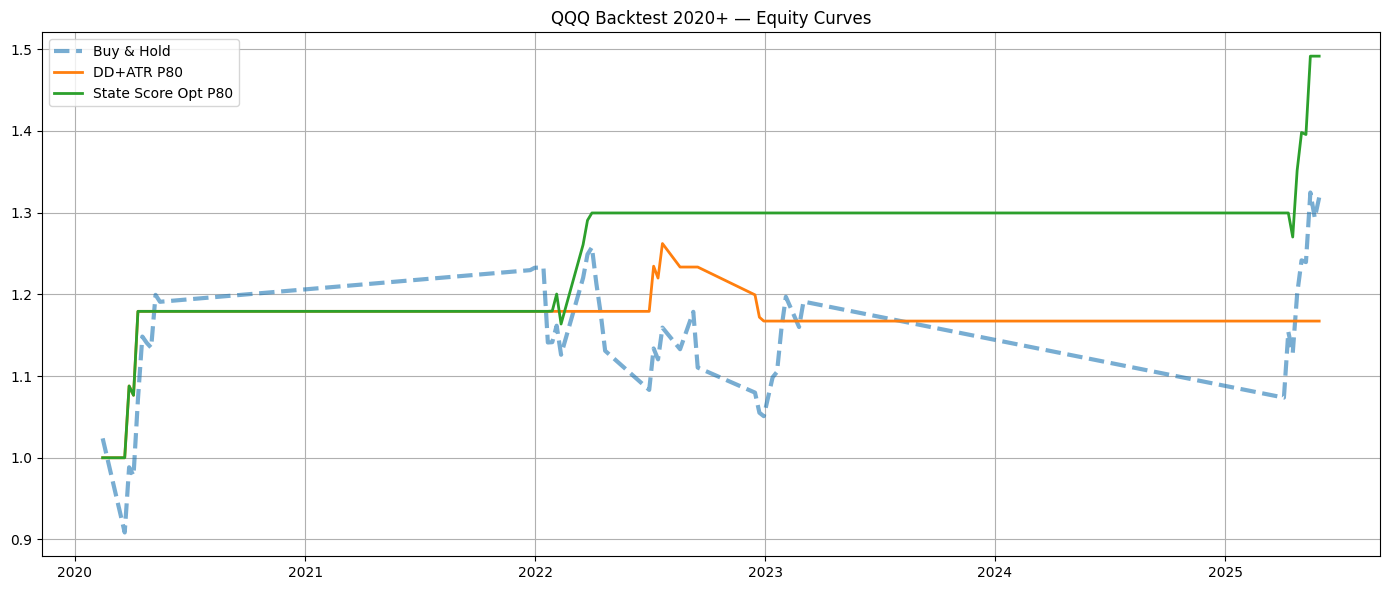

In [14]:
# ============================================================
# BLOQUE 4A — BACKTEST SIMPLE 2020+
# ============================================================

bt = df_scores.loc["2020":].copy()
print(f"Período: {bt.index.min().date()} → {bt.index.max().date()}  |  {len(bt):,} obs")

# Agregar ranks al dataset de backtest
bt["dd_rank"]  = bt["drawdown"].rank(pct=True, ascending=False)
bt["atr_rank"] = bt["atr_pct"].rank(pct=True)
bt["score_dd_atr"] = 0.5 * bt["dd_rank"] + 0.5 * bt["atr_rank"]

dd_thr  = bt["score_dd_atr"].quantile(0.80)
opt_thr = bt["state_score_opt"].quantile(0.80)

bt["pos_dd_atr"] = (bt["score_dd_atr"]  >= dd_thr).astype(int)
bt["pos_opt"]    = (bt["state_score_opt"] >= opt_thr).astype(int)

eq_bh     = (1 + bt["returns"]).cumprod()
eq_dd_atr = (1 + bt["returns"] * bt["pos_dd_atr"].shift(1).fillna(0)).cumprod()
eq_opt    = (1 + bt["returns"] * bt["pos_opt"].shift(1).fillna(0)).cumprod()

summary = []
for name, eq, ret_col in [("Buy & Hold", eq_bh, "returns"),
                            ("DD+ATR P80",  eq_dd_atr, None),
                            ("State Opt P80", eq_opt, None)]:
    total, cagr, mdd = get_stats(eq)
    summary.append({"strategy": name, "total_return": total, "cagr": cagr, "max_dd": mdd})

print("\nCOMPARATIVA SIMPLE — BACKTEST 2020+")
display(pd.DataFrame(summary).round(4))
print(f"Exposure DD+ATR  : {bt['pos_dd_atr'].mean():.1%}")
print(f"Exposure StateOpt: {bt['pos_opt'].mean():.1%}")

plt.figure(figsize=(14, 6))
plt.plot(eq_bh,     label="Buy & Hold",        linewidth=3, alpha=0.6, linestyle="--")
plt.plot(eq_dd_atr, label="DD+ATR P80",         linewidth=2)
plt.plot(eq_opt,    label="State Score Opt P80", linewidth=2)
plt.title("QQQ Backtest 2020+ — Equity Curves"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 4B — Threshold Test: Score DD+ATR con Holding Fijo de 12 Semanas

Evaluamos tres umbrales de entrada (P50, P65, P80) con el mismo holding de 12 semanas
para aislar el efecto del nivel de exigencia de la señal.


THRESHOLD TEST — SCORE DD+ATR  (Hold=12w)


,threshold,score_level,total_return,cagr,max_dd,exposure
0,P50,0.5104,0.5073,0.0807,-0.1401,0.5208
1,P65,0.5578,0.5700,0.0890,-0.1084,0.3542
2,P80,0.7312,0.3431,0.0574,-0.1084,0.2083


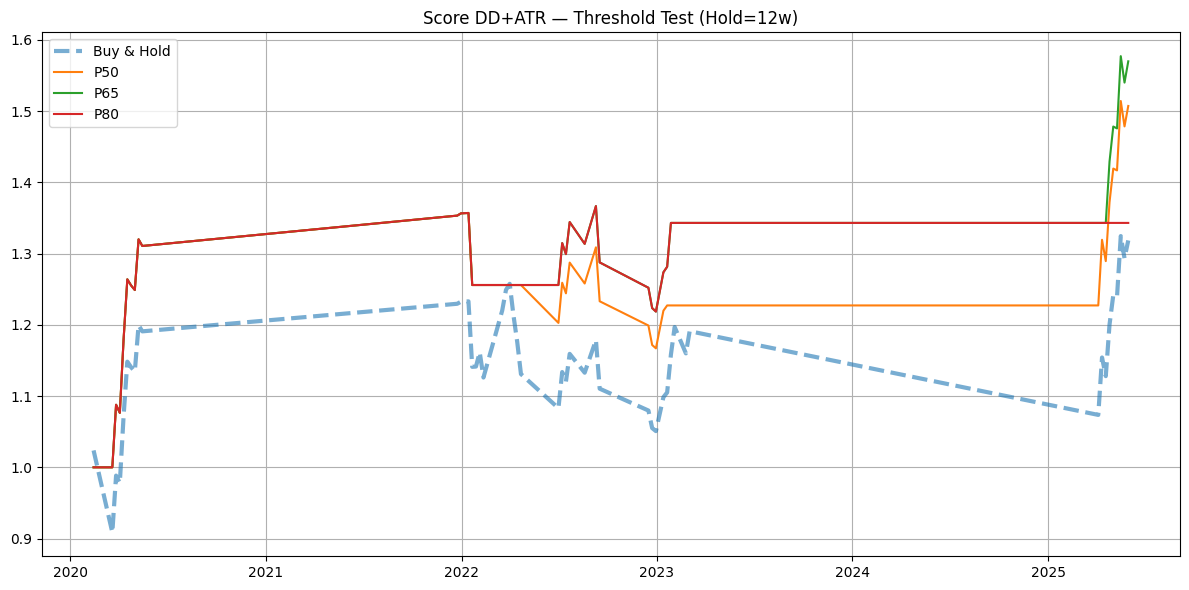

In [15]:
# ============================================================
# BLOQUE 4B — THRESHOLD TEST — SCORE DD+ATR  (Hold 12w)
# ============================================================

def run_holding_strategy(data, score_col, quantile, hold_weeks, tp=None):
    """Event-driven backtest: entra al trigger, mantiene hold_weeks (o TP si especificado)."""
    threshold = data[score_col].quantile(quantile)
    signal    = (data[score_col] >= threshold)

    equity     = [1.0]
    position   = 0
    weeks_held = 0
    entry_eq   = None

    for i in range(1, len(data)):
        ret = data["returns"].iloc[i]
        if position == 0:
            if signal.iloc[i - 1]:
                position = 1; weeks_held = 0; entry_eq = equity[-1]
        else:
            weeks_held += 1
            exit_tp   = tp is not None and (equity[-1] / entry_eq - 1) >= tp
            exit_time = weeks_held >= hold_weeks
            if exit_tp or exit_time:
                position = 0
        equity.append(equity[-1] * (1 + ret) if position else equity[-1])
    return pd.Series(equity, index=data.index), threshold, signal.mean()

rows, equities = [], {}
for name, q in [("P50", 0.50), ("P65", 0.65), ("P80", 0.80)]:
    eq, thr, exp = run_holding_strategy(bt, "score_dd_atr", q, hold_weeks=12)
    equities[name] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"threshold": name, "score_level": round(thr,4), "total_return": total,
                 "cagr": cagr, "max_dd": mdd, "exposure": exp})

bh = (1 + bt["returns"]).cumprod()
print("THRESHOLD TEST — SCORE DD+ATR  (Hold=12w)"); display(pd.DataFrame(rows).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("Score DD+ATR — Threshold Test (Hold=12w)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 4C — Holding Period Test: P65

Fijamos el umbral en P65 y variamos la duración del holding (4, 8, 12, 24 semanas)
para entender si la señal es de corto plazo (fuerza que se agota rápido) o
de medio plazo (persistencia de régimen).


HOLDING PERIOD TEST — SCORE DD+ATR P65


,holding_weeks,total_return,cagr,max_dd,exposure
0,4,0.6556,0.1000,-0.0752,0.3542
1,8,0.6394,0.0980,-0.1048,0.3542
2,12,0.5700,0.0890,-0.1084,0.3542
3,24,0.4026,0.0661,-0.1924,0.3542


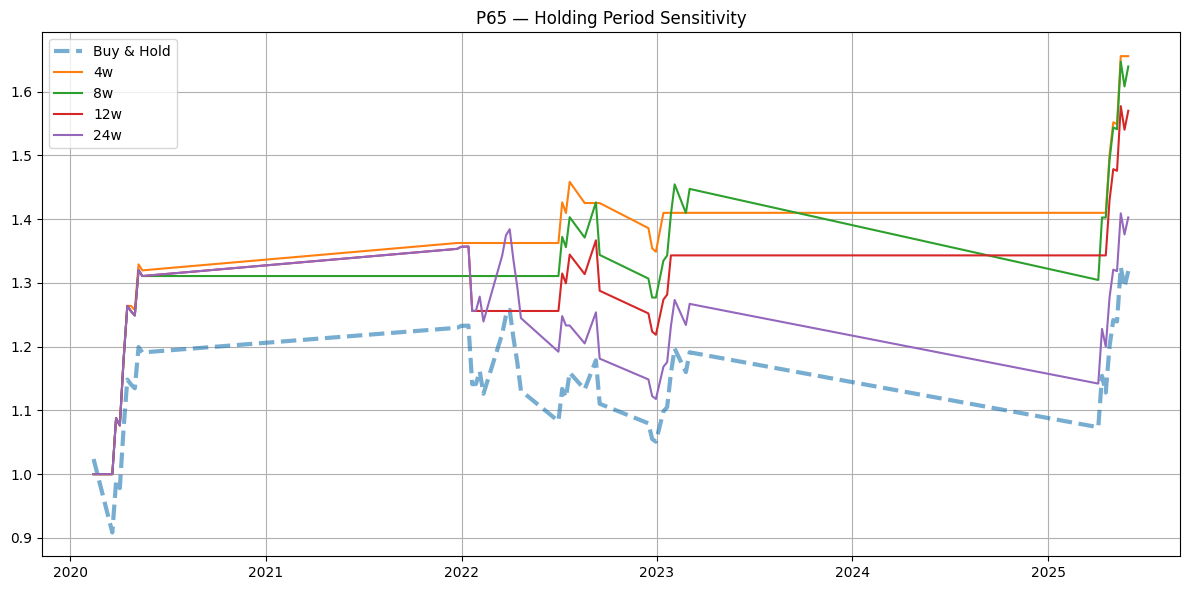

In [16]:
# ============================================================
# BLOQUE 4C — HOLDING PERIOD TEST — P65
# ============================================================

rows, equities = [], {}
for hold in [4, 8, 12, 24]:
    eq, _, exp = run_holding_strategy(bt, "score_dd_atr", 0.65, hold_weeks=hold)
    equities[f"{hold}w"] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"holding_weeks": hold, "total_return": total, "cagr": cagr, "max_dd": mdd, "exposure": exp})

print("HOLDING PERIOD TEST — SCORE DD+ATR P65"); display(pd.DataFrame(rows).sort_values("cagr", ascending=False).round(4))

bh = (1 + bt["returns"]).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("P65 — Holding Period Sensitivity"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 4D — Take Profit Test: P65 + Hold 8w

Agregamos una cláusula de take profit (TP) sobre la estrategia P65 + 8 semanas.
La idea es cerrar temprano si el trade alcanza un retorno objetivo, liberando capital.

Probamos TP 10% y 15%.


P65 + Hold 8w — TAKE PROFIT TEST


,strategy,total_return,cagr,max_dd,exposure
0,TP 10%,0.3947,0.0649,-0.1048,0.3542
1,TP 15%,0.4828,0.0773,-0.1048,0.3542


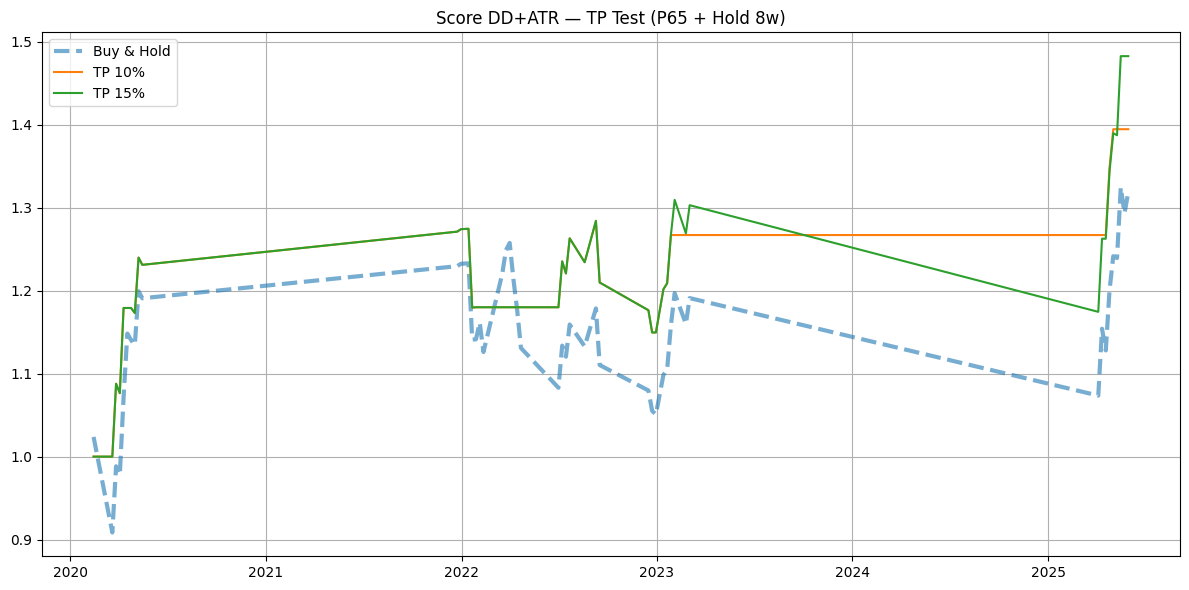

In [17]:
# ============================================================
# BLOQUE 4D — TAKE PROFIT TEST — P65 + Hold 8w
# ============================================================

rows, equities = [], {}
bh = (1 + bt["returns"]).cumprod()

for tp_val in [0.10, 0.15]:
    eq, _, exp = run_holding_strategy(bt, "score_dd_atr", 0.65, hold_weeks=8, tp=tp_val)
    label = f"TP {int(tp_val*100)}%"
    equities[label] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"strategy": label, "total_return": total, "cagr": cagr, "max_dd": mdd, "exposure": exp})

print("P65 + Hold 8w — TAKE PROFIT TEST"); display(pd.DataFrame(rows).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("Score DD+ATR — TP Test (P65 + Hold 8w)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 4E — Filtro de Tendencia: P70 + Trend

Evaluamos si agregar un filtro de tendencia positiva (`trend_13_52 > 0`) sobre el umbral P70
reduce el drawdown o mejora el CAGR. La idea es evitar entrar cuando el mercado está en
corrección estructural aunque el score de DD+ATR sea alto.


P70 vs P70 + TREND FILTER  (Hold=8w, TP=15%)


,strategy,total_return,cagr,max_dd,exposure
0,P70,0.4828,0.0773,-0.1048,0.3125
1,P70 + Trend,0.3858,0.0636,-0.0745,0.1458


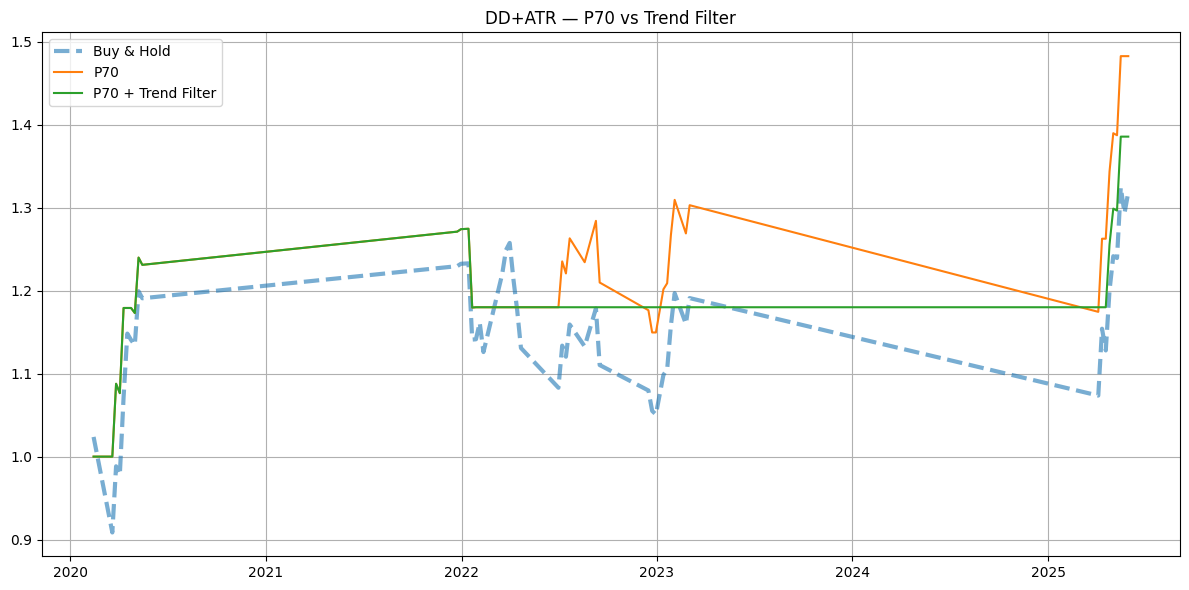

In [18]:
# ============================================================
# BLOQUE 4E — P70 + TREND FILTER
# ============================================================

def run_signal_backtest(data, signal, hold_weeks=8, tp=0.15):
    """Backtest con hold y TP sobre una Serie booleana de señal."""
    equity   = [1.0]
    position = 0; weeks = 0; entry_eq = None
    for i in range(1, len(data)):
        ret = data["returns"].iloc[i]
        if position == 0:
            if signal.iloc[i - 1]:
                position = 1; weeks = 0; entry_eq = equity[-1]
        else:
            weeks += 1
            if (equity[-1] / entry_eq - 1) >= tp or weeks >= hold_weeks:
                position = 0
        equity.append(equity[-1] * (1 + ret) if position else equity[-1])
    return pd.Series(equity, index=data.index)

thr70 = bt["score_dd_atr"].quantile(0.70)
sig_p70       = bt["score_dd_atr"] >= thr70
sig_p70_trend = (bt["score_dd_atr"] >= thr70) & (bt["trend_13_52"] > 0)

eq_p70       = run_signal_backtest(bt, sig_p70)
eq_p70_trend = run_signal_backtest(bt, sig_p70_trend)
bh           = (1 + bt["returns"]).cumprod()

rows = []
for name, eq, sig in [("P70", eq_p70, sig_p70), ("P70 + Trend", eq_p70_trend, sig_p70_trend)]:
    total, cagr, mdd = get_stats(eq)
    rows.append({"strategy": name, "total_return": total, "cagr": cagr, "max_dd": mdd, "exposure": sig.mean()})

print("P70 vs P70 + TREND FILTER  (Hold=8w, TP=15%)")
display(pd.DataFrame(rows).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
plt.plot(eq_p70,       label="P70")
plt.plot(eq_p70_trend, label="P70 + Trend Filter")
plt.title("DD+ATR — P70 vs Trend Filter"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 4F — Rolling Backtest: Score DD+ATR

Dividimos el período disponible en ventanas de 2 años superpuestas para evaluar si
la estrategia P70 + Hold 8w + TP 15% es consistente a lo largo del tiempo o si
sus resultados se concentran en una ventana específica.

Un CAGR positivo en la mayoría de ventanas es evidencia de robustez temporal.


ROLLING BACKTEST — SCORE DD+ATR  (P70, Hold=8w, TP=15%)


,window,total_return,cagr,max_dd,exposure
0,2020-2022,0.1488,0.0494,-0.1048,0.3636
1,2021-2023,0.1043,0.0870,-0.1048,0.3103
2,2022-2024,0.1043,0.0917,-0.1048,0.2963


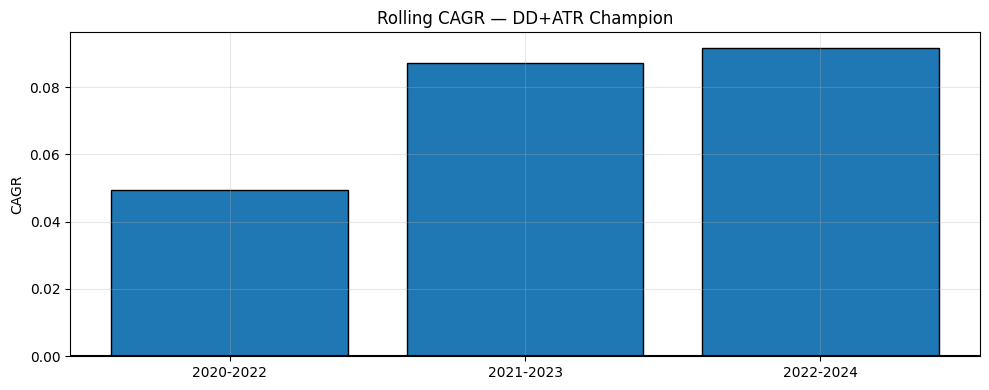

In [19]:
# ============================================================
# BLOQUE 4F — ROLLING BACKTEST — SCORE DD+ATR
# ============================================================

windows_roll = [("2020","2022"),("2021","2023"),("2022","2024"),("2023","2025")]
rows = []

for start, end in windows_roll:
    tmp = df_scores.loc[start:end].copy()
    if len(tmp) < 20: continue
    tmp["dd_rank"]      = tmp["drawdown"].rank(pct=True, ascending=False)
    tmp["atr_rank"]     = tmp["atr_pct"].rank(pct=True)
    tmp["score_dd_atr"] = 0.5 * tmp["dd_rank"] + 0.5 * tmp["atr_rank"]

    thr = tmp["score_dd_atr"].quantile(0.70)
    sig = tmp["score_dd_atr"] >= thr
    eq  = run_signal_backtest(tmp, sig, hold_weeks=8, tp=0.15)
    total, cagr, mdd = get_stats(eq)
    rows.append({"window": f"{start}-{end}", "total_return": total, "cagr": cagr,
                 "max_dd": mdd, "exposure": sig.mean()})

rolling_A = pd.DataFrame(rows)
print("ROLLING BACKTEST — SCORE DD+ATR  (P70, Hold=8w, TP=15%)")
display(rolling_A.round(4))

plt.figure(figsize=(10, 4))
plt.bar(rolling_A["window"], rolling_A["cagr"], edgecolor="black")
plt.axhline(0, color="black"); plt.title("Rolling CAGR — DD+ATR Champion"); plt.ylabel("CAGR")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 📊 Parte 5 — Backtest: Universo B — State Score Opt
### BLOQUE 5A — Threshold Test: State Score Opt

A diferencia del campeón A (que usa un backtest event-driven), testeamos primero
el `state_score_opt` con seguimiento semanal continuo (posición = 1 si el score
supera el umbral esa semana) para ver si el alpha proviene de los **estados** o
de las **transiciones de entrada** a esos estados.

Probamos P50, P60, P70, P80.


THRESHOLD TEST — STATE SCORE OPT  (seguimiento continuo)


,threshold,score_level,total_return,cagr,max_dd,exposure,transitions
2,P70,3.0,0.7187,0.1078,-0.0306,0.3333,3
0,P50,2.8,0.5160,0.0818,-0.1388,0.5625,6
1,P60,2.8,0.5160,0.0818,-0.1388,0.5625,6
3,P80,3.2,0.4915,0.0785,-0.0306,0.2917,3


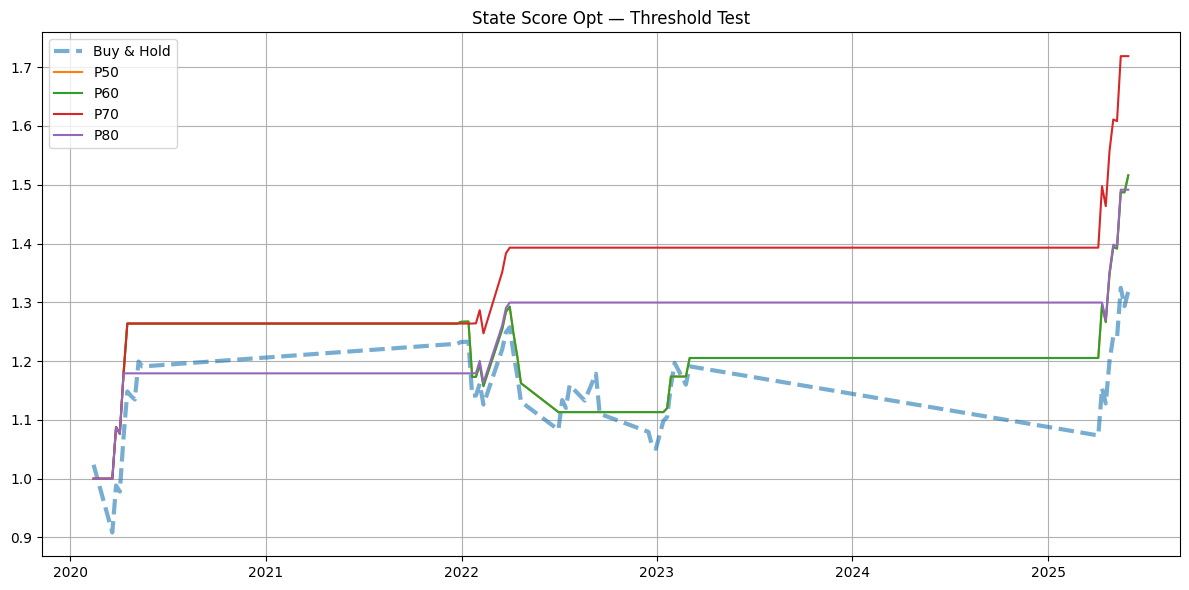

In [20]:
# ============================================================
# BLOQUE 5A — THRESHOLD TEST — STATE SCORE OPT  (seguimiento continuo)
# ============================================================

rows, equities = [], {}
bh = (1 + bt["returns"]).cumprod()

for pct in [50, 60, 70, 80]:
    level = bt["state_score_opt"].quantile(pct / 100)
    pos   = (bt["state_score_opt"] >= level).astype(int)
    ret_s = pos.shift(1).fillna(0) * bt["returns"]
    eq    = (1 + ret_s).cumprod()
    equities[f"P{pct}"] = eq
    total, cagr, mdd = get_stats(eq)
    trades = (pos.diff().eq(1)).sum()
    rows.append({"threshold": f"P{pct}", "score_level": round(level,3),
                 "total_return": total, "cagr": cagr, "max_dd": mdd,
                 "exposure": pos.mean(), "transitions": trades})

print("THRESHOLD TEST — STATE SCORE OPT  (seguimiento continuo)")
display(pd.DataFrame(rows).sort_values("cagr", ascending=False).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("State Score Opt — Threshold Test"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 5B — Holding Period Test: State Score Opt P70

Evaluamos si el alpha del `state_score_opt` es más fuerte con holding corto o largo.
Usamos P70 como umbral base (mostró mejor balance en el bloque anterior).


HOLDING PERIOD TEST — STATE SCORE OPT P70


,holding_weeks,total_return,cagr,max_dd,exposure
1,8,0.6594,0.1005,-0.0647,0.3333
2,12,0.5666,0.0886,-0.1388,0.3333
3,24,0.5146,0.0816,-0.1388,0.3333
0,4,0.5056,0.0804,-0.1007,0.3333


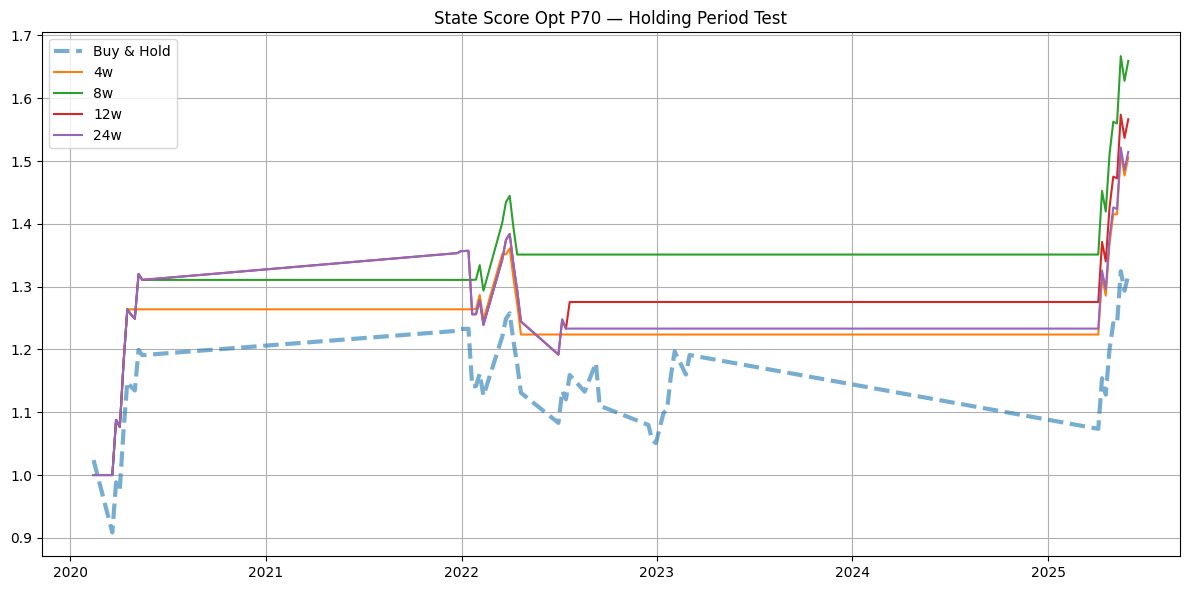

In [21]:
# ============================================================
# BLOQUE 5B — HOLDING PERIOD TEST — STATE SCORE OPT P70
# ============================================================

level_opt = bt["state_score_opt"].quantile(0.70)
sig_opt   = bt["state_score_opt"] >= level_opt

rows, equities = [], {}
bh = (1 + bt["returns"]).cumprod()

for hold in [4, 8, 12, 24]:
    eq  = run_holding_strategy(bt, "state_score_opt", 0.70, hold_weeks=hold)[0]
    equities[f"{hold}w"] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"holding_weeks": hold, "total_return": total, "cagr": cagr,
                 "max_dd": mdd, "exposure": sig_opt.mean()})

print("HOLDING PERIOD TEST — STATE SCORE OPT P70")
display(pd.DataFrame(rows).sort_values("cagr", ascending=False).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("State Score Opt P70 — Holding Period Test"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 5C — Rolling Backtest y Estabilidad de Umbral: State Score Opt

Combinamos el test de estabilidad de umbral (P65 a P80 con Hold=8w) y el rolling
backtest para evaluar si los resultados del Universo B son consistentes en el tiempo
y no dependen de un umbral exacto.


THRESHOLD STABILITY — STATE SCORE OPT  (Hold=8w)


,threshold,score_level,total_return,cagr,max_dd,exposure
1,P70,3.0,0.6594,0.1005,-0.0647,0.3333
2,P75,3.2,0.5435,0.0855,-0.0859,0.2917
3,P80,3.2,0.5435,0.0855,-0.0859,0.2917
0,P65,2.8,0.3529,0.0588,-0.1388,0.5625


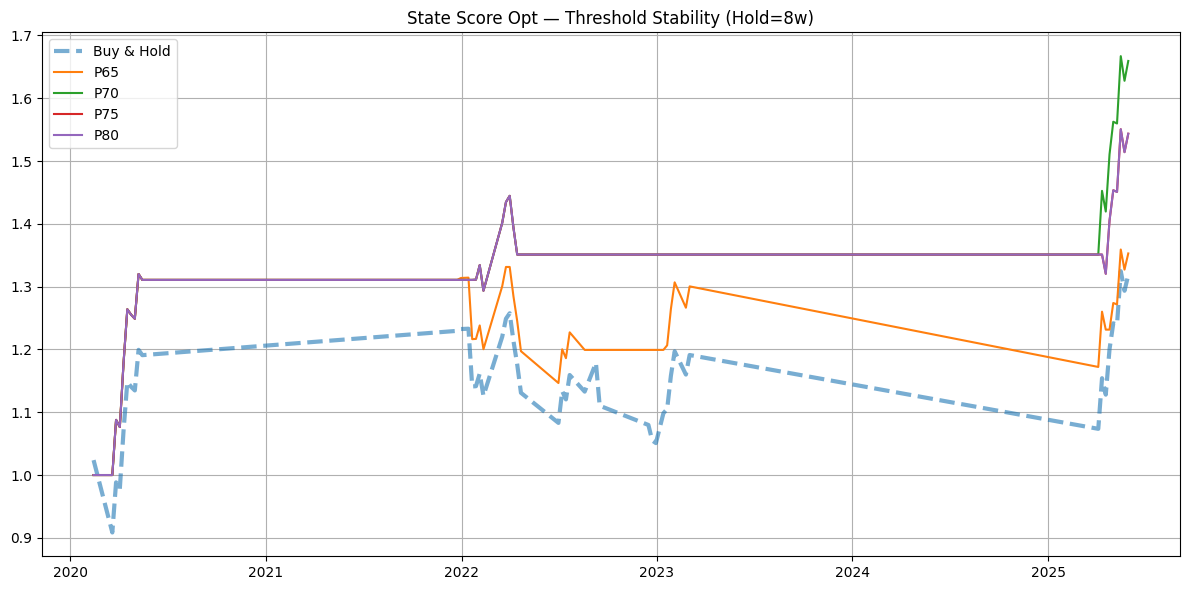


ROLLING BACKTEST — STATE SCORE OPT  (P70, Hold=8w)


,window,total_return,cagr,max_dd,exposure
0,2020-2022,0.3511,0.1104,-0.0647,0.3030
1,2021-2023,-0.0079,-0.0066,-0.1388,0.5517
2,2022-2024,0.0075,0.0066,-0.1115,0.5185


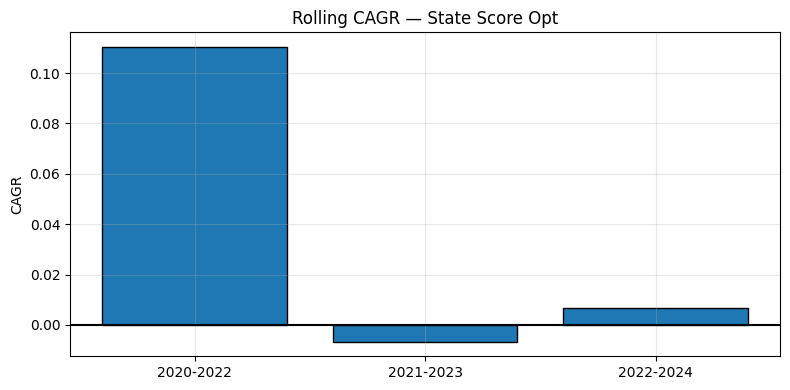

In [22]:
# ============================================================
# BLOQUE 5C — THRESHOLD STABILITY + ROLLING — STATE SCORE OPT
# ============================================================

# ── Stability de umbral (Hold=8w) ────────────────────────
rows, equities = [], {}
bh = (1 + bt["returns"]).cumprod()

for pct in [65, 70, 75, 80]:
    eq, thr, exp = run_holding_strategy(bt, "state_score_opt", pct/100, hold_weeks=8)
    equities[f"P{pct}"] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"threshold": f"P{pct}", "score_level": round(thr,3),
                 "total_return": total, "cagr": cagr, "max_dd": mdd, "exposure": exp})

print("THRESHOLD STABILITY — STATE SCORE OPT  (Hold=8w)")
display(pd.DataFrame(rows).sort_values("cagr", ascending=False).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("State Score Opt — Threshold Stability (Hold=8w)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── Rolling Backtest ──────────────────────────────────────
rows_r = []
for start, end in windows_roll[:3]:
    tmp = df_scores.loc[start:end].copy()
    if len(tmp) < 20: continue
    eq, _, exp = run_holding_strategy(tmp, "state_score_opt", 0.70, hold_weeks=8)
    total, cagr, mdd = get_stats(eq)
    rows_r.append({"window": f"{start}-{end}", "total_return": total, "cagr": cagr,
                   "max_dd": mdd, "exposure": exp})

rolling_B = pd.DataFrame(rows_r)
print("\nROLLING BACKTEST — STATE SCORE OPT  (P70, Hold=8w)")
display(rolling_B.round(4))

plt.figure(figsize=(8, 4))
plt.bar(rolling_B["window"], rolling_B["cagr"], edgecolor="black")
plt.axhline(0, color="black"); plt.title("Rolling CAGR — State Score Opt"); plt.ylabel("CAGR")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 🔗 Parte 6 — Ensambles y Combinaciones
### AND y OR como estrategias candidatas

Los backtests individuales de las Partes 4 y 5 establecieron los parámetros operativos
de cada componente. La Parte 6 combina esos componentes y evalúa **AND** y **OR**
con el mismo nivel de análisis que recibieron individualmente.

**Estructura de esta parte:**

| Bloque | Contenido |
|--------|-----------|
| 6A | Comparativa inicial: AND / OR / Singles sin holding (seguimiento continuo) |
| 6B | DD+ATR con filtro OPT (event-driven) |
| 6C | Rolling Championship ampliado: DD vs OPT vs OR vs AND |
| 6D | **OR Champion con holding — Backtest** |
| 6E | **AND vs OR — Robustness Grid (lado a lado)** |
| 6F | **OR Champion — Rolling Test** |
| 6G | **AND vs OR — Comparación Operacional Directa** |

El objetivo no es demostrar que uno es "mejor" que el otro, sino entender sus
**diferencias operacionales** respaldadas por evidencia cuantitativa:

> **AND (selectividad):** menor exposición, menor MDD, mayor CAGR por unidad de riesgo.
> **OR (cobertura):** mayor exposición, mayor retorno total, mayor drawdown potencial.

ENSEMBLE TEST — AND / OR / Singles  (seguimiento, 2010+)


,strategy,total_return,cagr,max_dd,exposure,entries
2,OR,1.1038,0.0496,-0.1475,0.4727,14
1,StateOpt,1.0903,0.0491,-0.1388,0.3636,17
0,DD+ATR,0.7433,0.0368,-0.0773,0.2000,6
3,AND,0.7321,0.0364,-0.0307,0.0909,7



Score 50/50 — Spearman=0.2284  Spread=+0.0639


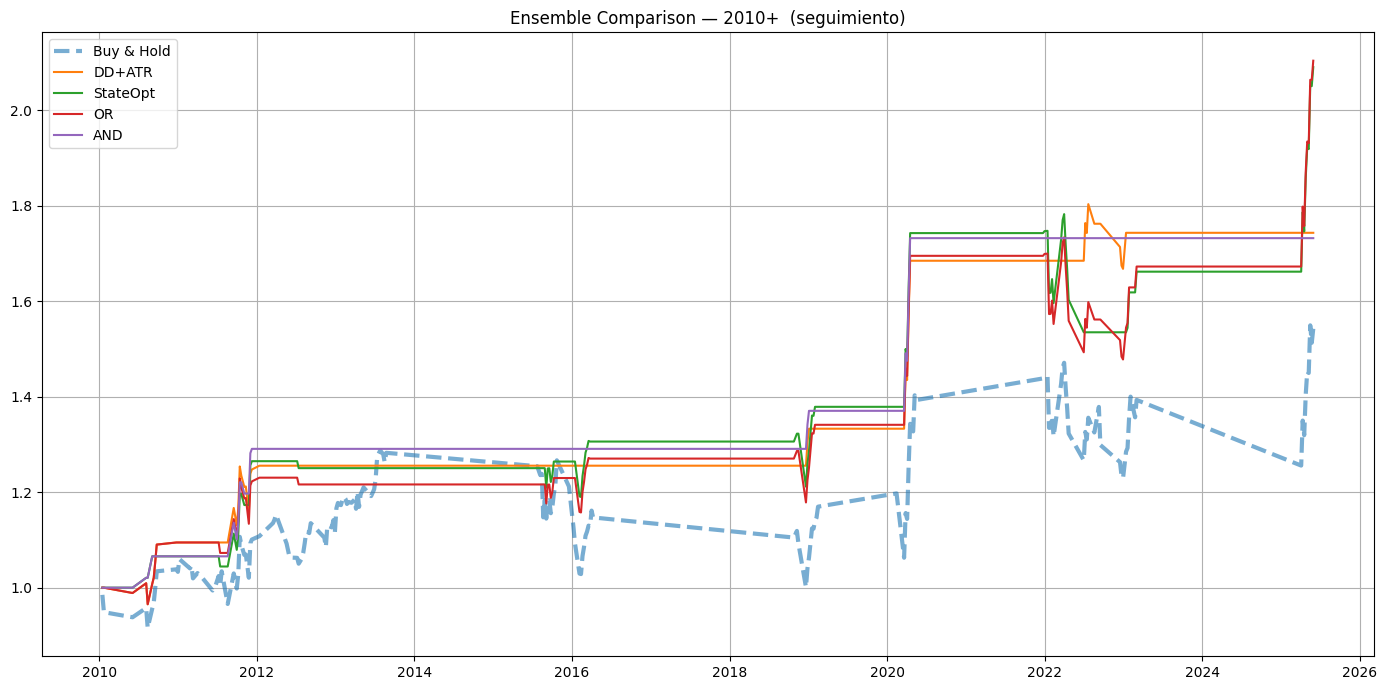

In [23]:
# ============================================================
# BLOQUE 6A — AND / OR / Score 50/50
# ============================================================

df_modern = df_scores[df_scores.index.year >= 2010].copy()
df_modern["dd_rank"]       = df_modern["drawdown"].rank(pct=True, ascending=False)
df_modern["atr_rank"]      = df_modern["atr_pct"].rank(pct=True)
df_modern["score_dd_atr"]  = 0.5 * df_modern["dd_rank"] + 0.5 * df_modern["atr_rank"]

DD_THR  = 0.65   # rango percentual fijo
OPT_THR = df_modern["state_score_opt"].quantile(0.70)

sig_dd  = df_modern["score_dd_atr"]    >= DD_THR
sig_opt = df_modern["state_score_opt"] >= OPT_THR
sig_or  = sig_dd | sig_opt
sig_and = sig_dd & sig_opt

# Score 50/50 continuo
df_modern["rank_opt"] = df_modern["state_score_opt"].rank(pct=True)
df_modern["ensemble_50"] = 0.5 * df_modern["score_dd_atr"] + 0.5 * df_modern["rank_opt"]

signals = {"DD+ATR": sig_dd, "StateOpt": sig_opt, "OR": sig_or, "AND": sig_and}
rows, eq_curves = [], {}
bh = (1 + df_modern["returns"]).cumprod()

for name, sig in signals.items():
    ret_s = df_modern["returns"] * sig.shift(1).fillna(False).astype(bool)
    eq = (1 + ret_s).cumprod()
    eq_curves[name] = eq
    total, cagr, mdd = get_stats(eq)
    transitions = (sig.astype(int).diff().fillna(0).eq(1)).sum()
    rows.append({"strategy": name, "total_return": total, "cagr": cagr, "max_dd": mdd,
                 "exposure": sig.mean(), "entries": transitions})

print("ENSEMBLE TEST — AND / OR / Singles  (seguimiento, 2010+)")
display(pd.DataFrame(rows).sort_values("cagr", ascending=False).round(4))

# Score 50/50
tmp50 = df_modern[["ensemble_50","fwd_ret_12"]].dropna().copy()
corr50, p50 = spearmanr(tmp50["ensemble_50"], tmp50["fwd_ret_12"])
tmp50["q"] = pd.qcut(tmp50["ensemble_50"], 5, labels=False)
spread50 = tmp50.groupby("q")["fwd_ret_12"].mean()
print(f"\nScore 50/50 — Spearman={corr50:.4f}  Spread={spread50.iloc[-1]-spread50.iloc[0]:+.4f}")

plt.figure(figsize=(14, 7))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in eq_curves.items():
    plt.plot(eq, label=name)
plt.title("Ensemble Comparison — 2010+  (seguimiento)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 6B — DD+ATR como Señal Base con Filtro OPT

Probamos usar DD+ATR (event-driven, P70, Hold=8w, TP=15%) como señal principal y
agregar un filtro de confirmación basado en `state_score_opt` (P50, P60 o P70).

Esto reduce la cantidad de trades pero busca los de mayor probabilidad de éxito.


DD+ATR P70 + FILTRO STATE SCORE OPT  (Hold=8w, TP=15%)


,filter,total_return,cagr,max_dd,exposure,entries
0,DD P70 + OPT P50,0.7676,0.0378,-0.1362,0.2121,35
1,DD P70 + OPT P60,0.6791,0.0343,-0.1046,0.1636,27
2,DD P70 + OPT P70,0.6791,0.0343,-0.1046,0.1394,23


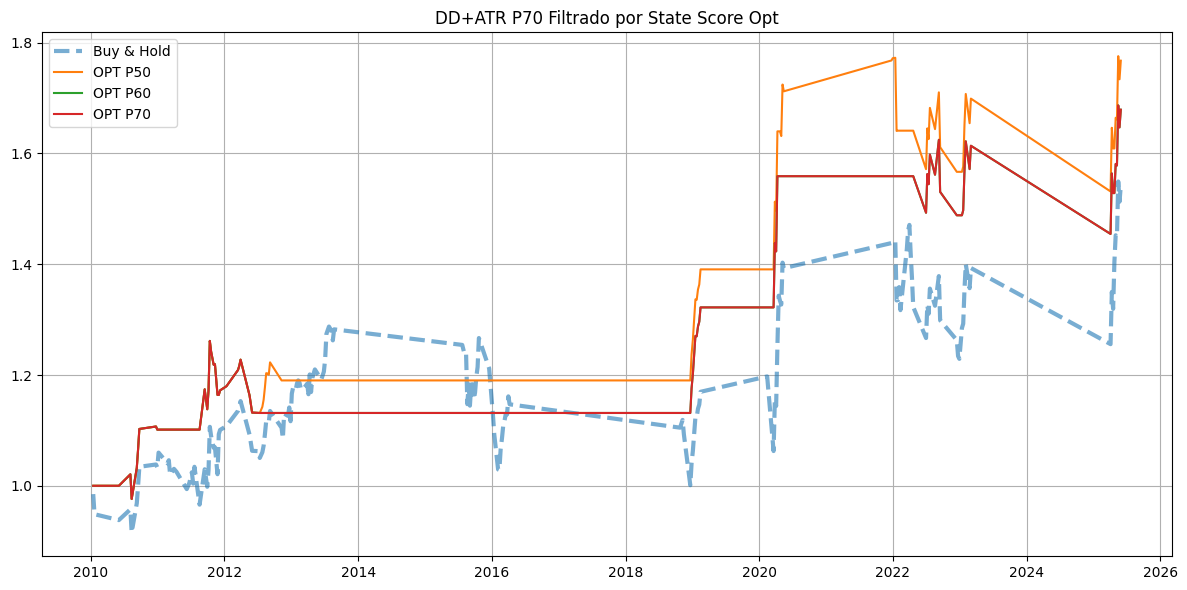

In [24]:
# ============================================================
# BLOQUE 6B — DD+ATR P70 + FILTRO OPT
# ============================================================

thr_dd  = df_modern["score_dd_atr"].quantile(0.70)
rows, equities = [], {}
bh = (1 + df_modern["returns"]).cumprod()

for pct, opt_q in [(50, 0.50), (60, 0.60), (70, 0.70)]:
    opt_q_val = df_modern["state_score_opt"].quantile(opt_q)
    combined  = (df_modern["score_dd_atr"] >= thr_dd) & (df_modern["state_score_opt"] >= opt_q_val)
    eq = run_signal_backtest(df_modern, combined, hold_weeks=8, tp=0.15)
    equities[f"OPT P{pct}"] = eq
    total, cagr, mdd = get_stats(eq)
    rows.append({"filter": f"DD P70 + OPT P{pct}", "total_return": total, "cagr": cagr,
                 "max_dd": mdd, "exposure": combined.mean(), "entries": combined.sum()})

print("DD+ATR P70 + FILTRO STATE SCORE OPT  (Hold=8w, TP=15%)")
display(pd.DataFrame(rows).round(4))

plt.figure(figsize=(12, 6))
plt.plot(bh, label="Buy & Hold", linewidth=3, linestyle="--", alpha=0.6)
for name, eq in equities.items():
    plt.plot(eq, label=name)
plt.title("DD+ATR P70 Filtrado por State Score Opt"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 6C — Rolling Championship: DD+ATR vs StateOpt vs OR

Dividimos el período 2010–2025 en cinco ventanas de 5 años para evaluar qué estrategia
gana más frecuentemente y si existe un patrón de ciclo (algún régimen de mercado
favorece a una señal sobre la otra).


ROLLING CHAMPIONSHIP — DD+ATR vs OPT vs OR vs AND  (Hold=8w)


,window,DD_ATR_cagr,DD_ATR_mdd,OPT_cagr,OPT_mdd,OR_cagr,OR_mdd,AND_cagr,AND_mdd
0,2010-2014,0.0288,-0.0891,0.0763,-0.0885,0.0288,-0.0891,0.0349,-0.1031
1,2015-2019,0.0446,-0.0006,0.0334,-0.1053,0.0334,-0.1053,0.0446,-0.0006
2,2020-2025,0.0734,-0.1234,0.0588,-0.1388,0.0849,-0.1475,0.0674,-0.1046



  2010-2014  →  Ganador: OPT  (CAGR=7.63%)
  2015-2019  →  Ganador: DD_ATR  (CAGR=4.46%)
  2020-2025  →  Ganador: OR  (CAGR=8.49%)


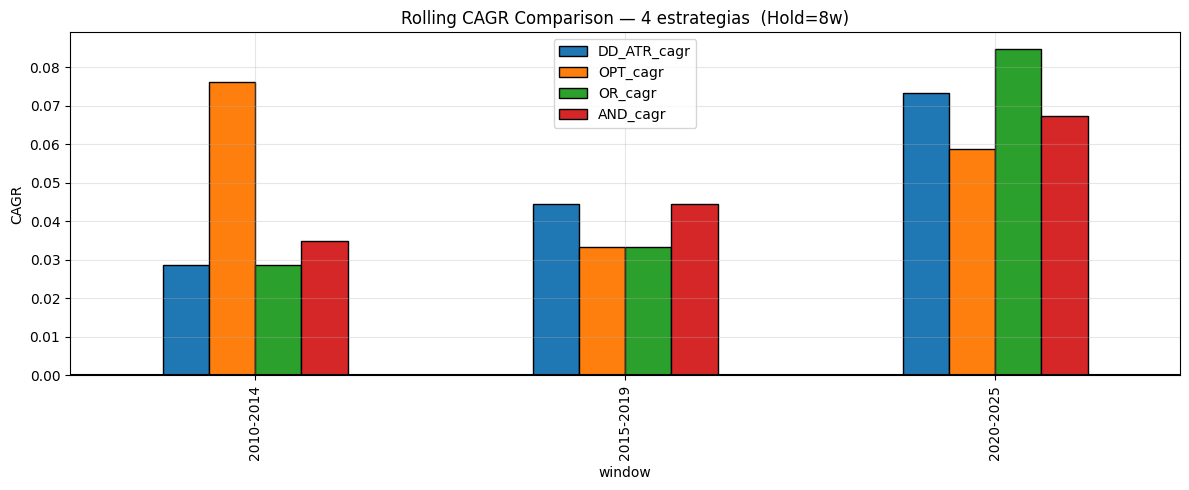

In [25]:
# ============================================================
# BLOQUE 6C — ROLLING CHAMPIONSHIP (ampliado: DD vs OPT vs OR vs AND)
# ============================================================

champ_windows = [(2010, 2014), (2015, 2019), (2020, 2025)]
thr_dd_g  = df_modern["score_dd_atr"].quantile(0.70)
thr_opt_g = df_modern["state_score_opt"].quantile(0.70)

rows = []
for start, end in champ_windows:
    tmp = df_modern[(df_modern.index.year >= start) & (df_modern.index.year <= end)].copy()
    if len(tmp) < 30:
        continue

    sig_dd_c  = tmp["score_dd_atr"]    >= thr_dd_g
    sig_opt_c = tmp["state_score_opt"] >= thr_opt_g
    sig_or_c  = sig_dd_c | sig_opt_c
    sig_and_c = sig_dd_c & sig_opt_c

    row = {"window": f"{start}-{end}"}
    for name, sig in [("DD_ATR", sig_dd_c), ("OPT", sig_opt_c),
                      ("OR", sig_or_c), ("AND", sig_and_c)]:
        eq = run_holding_backtest(tmp, sig, hold_weeks=8)
        total, cagr, mdd = get_stats(eq)
        row[f"{name}_cagr"] = cagr
        row[f"{name}_mdd"]  = mdd
    rows.append(row)

rolling_ch = pd.DataFrame(rows)
print("ROLLING CHAMPIONSHIP — DD+ATR vs OPT vs OR vs AND  (Hold=8w)")
display(rolling_ch.round(4))

# ── Ganador por ventana ───────────────────────────────────
print()
for _, row in rolling_ch.iterrows():
    winner = max(
        [("DD_ATR", row["DD_ATR_cagr"]), ("OPT", row["OPT_cagr"]),
         ("OR",  row["OR_cagr"]),  ("AND", row["AND_cagr"])],
        key=lambda x: x[1]
    )
    print(f"  {row['window']}  →  Ganador: {winner[0]}  (CAGR={winner[1]:.2%})")

cols_plot = ["DD_ATR_cagr", "OPT_cagr", "OR_cagr", "AND_cagr"]
rolling_ch.set_index("window")[cols_plot].plot(kind="bar", figsize=(12, 5), edgecolor="black")
plt.axhline(0, color="black")
plt.title("Rolling CAGR Comparison — 4 estrategias  (Hold=8w)")
plt.ylabel("CAGR"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### BLOQUE 6D — OR Champion con Holding: Backtest

El OR con holding hereda los parámetros operativos ya validados en Partes 4 y 5:
- **DD+ATR:** P65, Hold 4 semanas
- **State Score Opt:** P70, Hold 8 semanas

La posición OR está activa cuando **al menos uno** de los dos held-signals está activo.

> **Nota metodológica:** no se aplica un threshold test independiente para OR porque
> OR no tiene un único umbral — sus dos umbrales fueron analizados individualmente
> en las Partes 4 y 5. Lo que variaremos en el BLOQUE 6E es la estabilidad del
> resultado ante cambios en esa combinación (robustness grid).

OR vs AND vs BUY & HOLD — CON HOLDING (2010+)


,estrategia,total_return,cagr,max_dd,exposicion
1,OR (held),1.1259,0.0503,-0.1388,0.6545
2,AND (held),0.9319,0.0438,-0.0773,0.1879
0,Buy & Hold,0.5423,0.0286,-0.2225,1.0000



Exposición OR  : 65.5%  (108 semanas)
Exposición AND : 18.8%  (31 semanas)
Ratio OR/AND   : 3.5x más tiempo invertido en OR
Semanas OR sin AND (solo OR activo): 77


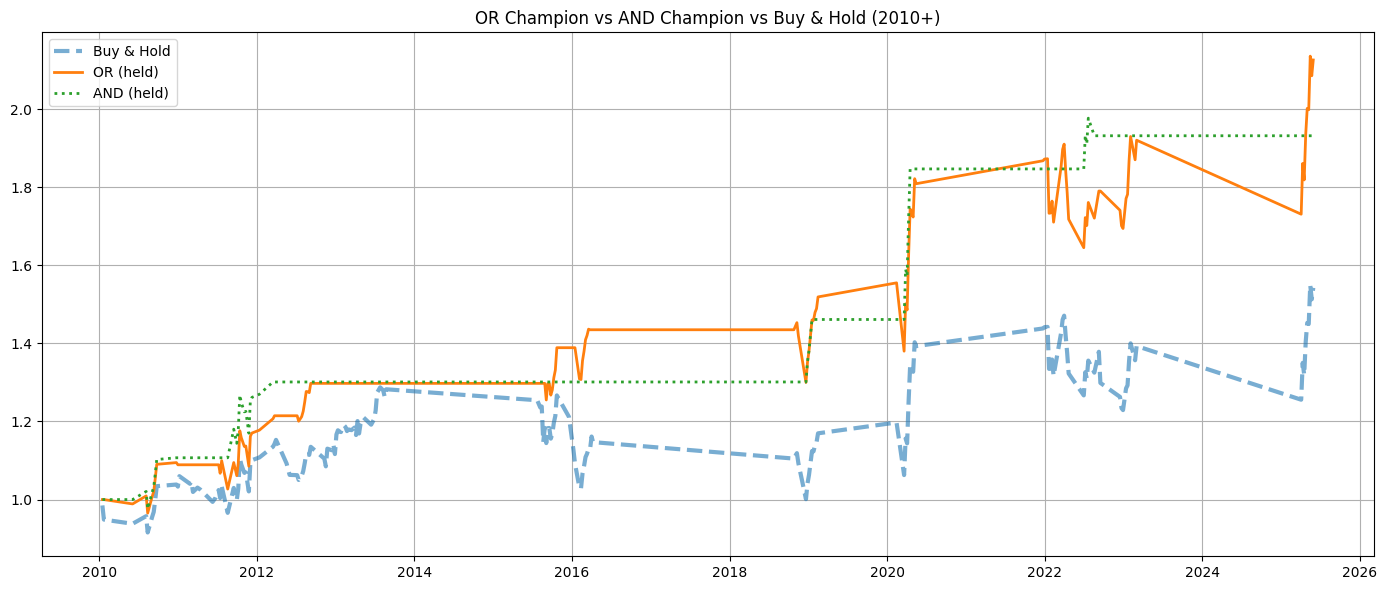

In [26]:
# ============================================================
# BLOQUE 6D — OR CHAMPION — BACKTEST CON HOLDING (2010+)
# ============================================================

# ── Señales base (mismos umbrales que el AND Champion) ───
dd_base_6d  = df_modern["score_dd_atr"]    >= DD_THR
opt_base_6d = df_modern["state_score_opt"] >= OPT_THR

dd_held_6d  = build_holding_signal(dd_base_6d,  4, df_modern.index)   # DD: Hold 4w
opt_held_6d = build_holding_signal(opt_base_6d, 8, df_modern.index)   # OPT: Hold 8w

or_held  = dd_held_6d | opt_held_6d   # OR: al menos uno activo
and_held = dd_held_6d & opt_held_6d   # AND: ambos activos (referencia directa)

ret_or  = df_modern["returns"] * or_held.shift(1).fillna(False).astype(bool)
ret_and = df_modern["returns"] * and_held.shift(1).fillna(False).astype(bool)
eq_or   = (1 + ret_or).cumprod()
eq_and  = (1 + ret_and).cumprod()
eq_bh   = (1 + df_modern["returns"]).cumprod()

total_or,  cagr_or,  mdd_or  = get_stats(eq_or)
total_and, cagr_and, mdd_and = get_stats(eq_and)
total_bh,  cagr_bh,  mdd_bh  = get_stats(eq_bh)

summary_6d = pd.DataFrame([
    {"estrategia": "Buy & Hold",
     "total_return": total_bh, "cagr": cagr_bh, "max_dd": mdd_bh, "exposicion": 1.0},
    {"estrategia": "OR (held)",
     "total_return": total_or, "cagr": cagr_or, "max_dd": mdd_or, "exposicion": or_held.mean()},
    {"estrategia": "AND (held)",
     "total_return": total_and, "cagr": cagr_and, "max_dd": mdd_and, "exposicion": and_held.mean()},
]).sort_values("cagr", ascending=False)

print("OR vs AND vs BUY & HOLD — CON HOLDING (2010+)")
display(summary_6d.round(4))

print(f"\nExposición OR  : {or_held.mean():.1%}  ({or_held.sum()} semanas)")
print(f"Exposición AND : {and_held.mean():.1%}  ({and_held.sum()} semanas)")
print(f"Ratio OR/AND   : {or_held.mean() / max(0.01, and_held.mean()):.1f}x más tiempo invertido en OR")
print(f"Semanas OR sin AND (solo OR activo): {(or_held & ~and_held).sum()}")

plt.figure(figsize=(14, 6))
plt.plot(eq_bh,  label="Buy & Hold",  linewidth=3, linestyle="--", alpha=0.6)
plt.plot(eq_or,  label="OR (held)",   linewidth=2)
plt.plot(eq_and, label="AND (held)",  linewidth=2, linestyle=":")
plt.title("OR Champion vs AND Champion vs Buy & Hold (2010+)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 6E — Robustness Grid: AND vs OR (lado a lado)

Variamos los umbrales de entrada de ambos componentes (DD Rank P60/P65/P70 ×
State Opt P65/P70/P75) y calculamos el CAGR resultante para AND y OR.

El criterio de robustez es el mismo que en el BLOQUE 7C del AND Champion:
**buscar mesetas estables, no picos aislados.** Un rango de CAGR pequeño en la
grilla indica que el resultado no depende de un par de parámetros exacto.

> El tamaño del rango (Max − Min) de la grilla sirve como proxy de sensibilidad
> a parámetros: un rango más pequeño equivale a una meseta más estable.

AND — Robustness Grid (CAGR 2010+)


,OPT P65,OPT P70,OPT P75
DD P60,0.0609,0.0609,0.0609
DD P65,0.0438,0.0438,0.0438
DD P70,0.0356,0.0356,0.0356



OR — Robustness Grid (CAGR 2010+)


,OPT P65,OPT P70,OPT P75
DD P60,0.0462,0.0462,0.0462
DD P65,0.0503,0.0503,0.0503
DD P70,0.0518,0.0518,0.0518


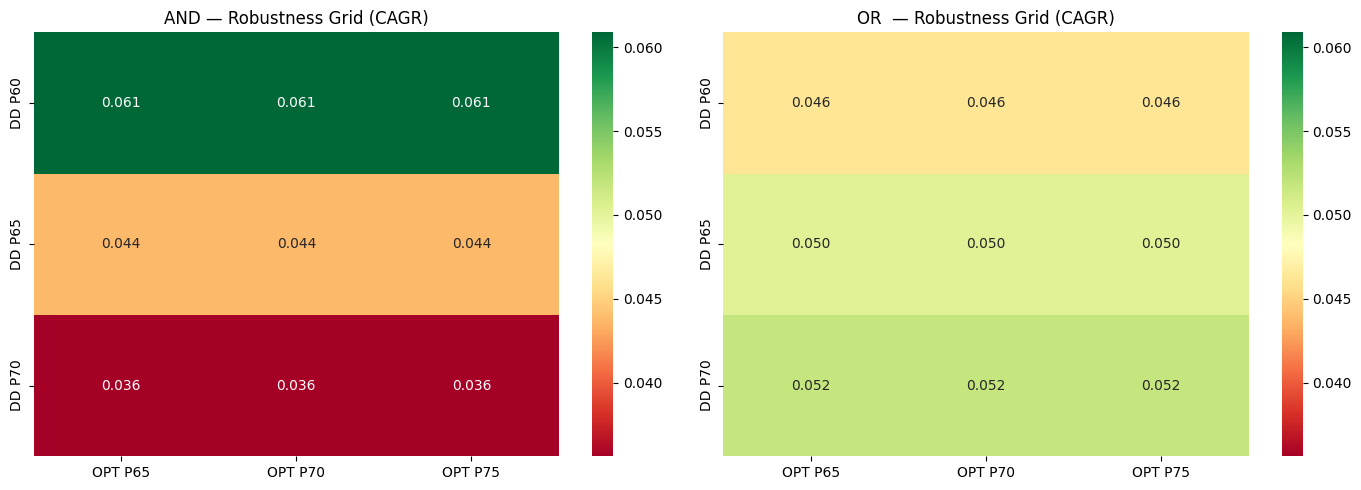


ESTABILIDAD DE PARÁMETROS (rango CAGR en la grilla)
  AND — Rango: 0.0253  (Min=0.0356 / Max=0.0609)
  OR  — Rango: 0.0056  (Min=0.0462 / Max=0.0518)

  Meseta más estable: OR (rango 0.0056 vs 0.0253)


In [27]:
# ============================================================
# BLOQUE 6E — ROBUSTNESS GRID: AND vs OR  (2010+)
# ============================================================

dd_levels_g  = [0.60, 0.65, 0.70]
opt_levels_g = [df_modern["state_score_opt"].quantile(q) for q in [0.65, 0.70, 0.75]]
idx_labels   = ["DD P60", "DD P65", "DD P70"]
col_labels   = ["OPT P65", "OPT P70", "OPT P75"]

grid_and_r, grid_or_r = [], []
for dd_t in dd_levels_g:
    row_and, row_or = [], []
    for opt_t in opt_levels_g:
        dd_b  = df_modern["score_dd_atr"]    >= dd_t
        opt_b = df_modern["state_score_opt"] >= opt_t
        sig_d = build_holding_signal(dd_b,  4, df_modern.index)
        sig_o = build_holding_signal(opt_b, 8, df_modern.index)
        for row_r, sig in [(row_and, sig_d & sig_o), (row_or, sig_d | sig_o)]:
            ret_s = df_modern["returns"] * sig.shift(1).fillna(False).astype(bool)
            eq    = (1 + ret_s).cumprod()
            _, cagr, _ = get_stats(eq)
            row_r.append(round(cagr, 4))
    grid_and_r.append(row_and)
    grid_or_r.append(row_or)

grid_and_df = pd.DataFrame(grid_and_r, index=idx_labels, columns=col_labels)
grid_or_df  = pd.DataFrame(grid_or_r,  index=idx_labels, columns=col_labels)

print("AND — Robustness Grid (CAGR 2010+)")
display(grid_and_df.round(4))
print("\nOR — Robustness Grid (CAGR 2010+)")
display(grid_or_df.round(4))

# ── Heatmaps comparativos ─────────────────────────────────
vmin = min(grid_and_df.values.min(), grid_or_df.values.min())
vmax = max(grid_and_df.values.max(), grid_or_df.values.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_g, title in [(axes[0], grid_and_df, "AND — Robustness Grid (CAGR)"),
                         (axes[1], grid_or_df,  "OR  — Robustness Grid (CAGR)")]:
    sns.heatmap(df_g, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=vmin, vmax=vmax, ax=ax)
    ax.set_title(title)
plt.tight_layout(); plt.show()

# ── Resumen de estabilidad ────────────────────────────────
and_range = grid_and_df.values.max() - grid_and_df.values.min()
or_range  = grid_or_df.values.max()  - grid_or_df.values.min()
print("\nESTABILIDAD DE PARÁMETROS (rango CAGR en la grilla)")
print(f"  AND — Rango: {and_range:.4f}  (Min={grid_and_df.values.min():.4f} / Max={grid_and_df.values.max():.4f})")
print(f"  OR  — Rango: {or_range:.4f}  (Min={grid_or_df.values.min():.4f} / Max={grid_or_df.values.max():.4f})")
print(f"\n  Meseta más estable: {'AND' if and_range <= or_range else 'OR'} "
      f"(rango {min(and_range, or_range):.4f} vs {max(and_range, or_range):.4f})")

### BLOQUE 6F — OR Champion: Rolling Test

Evaluamos el OR Champion en las mismas tres ventanas temporales que el AND Champion
(BLOQUE 7D), para comparar directamente su consistencia inter-período.

La pregunta es si el OR produce CAGR positivo en todas las ventanas o si su
resultado depende de un período específico.

ROLLING TEST — OR CHAMPION


,window,total_return,cagr,max_dd,exposure,weeks
0,2010-2014,0.2976,0.0750,-0.0773,0.4231,33
1,2015-2019,0.1706,0.0452,-0.1053,0.7179,28
2,2020-2025,0.4340,0.0705,-0.1475,0.9167,44



COMPARACIÓN ROLLING: OR vs AND


,window,OR_cagr,AND_cagr,OR_mdd,AND_mdd,OR_exp,AND_exp
0,2010-2014,0.0750,0.0758,-0.0773,-0.0773,0.4231,0.2436
1,2015-2019,0.0452,0.0331,-0.1053,0.0000,0.7179,0.1026
2,2020-2025,0.0705,0.0588,-0.1475,-0.0118,0.9167,0.1458


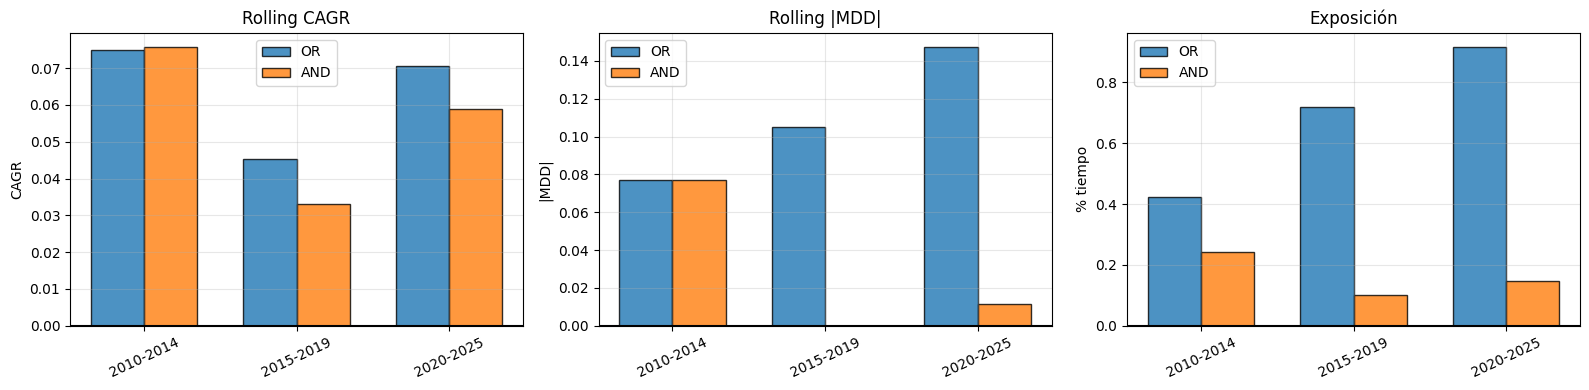

In [28]:
# ============================================================
# BLOQUE 6F — OR CHAMPION — ROLLING TEST
# ============================================================

rows_or_r, rows_and_r = [], []
for start, end in champ_windows:
    tmp = df_modern[(df_modern.index.year >= start) & (df_modern.index.year <= end)].copy()
    if len(tmp) < 30:
        continue
    tmp_dd  = tmp["score_dd_atr"]    >= DD_THR
    tmp_opt = tmp["state_score_opt"] >= OPT_THR
    sig_d   = build_holding_signal(tmp_dd,  4, tmp.index)
    sig_o   = build_holding_signal(tmp_opt, 8, tmp.index)

    for rows_r, sig, label in [(rows_or_r, sig_d | sig_o, "OR"),
                                (rows_and_r, sig_d & sig_o, "AND")]:
        ret_s = tmp["returns"] * sig.shift(1).fillna(False).astype(bool)
        eq    = (1 + ret_s).cumprod()
        total, cagr, mdd = get_stats(eq)
        rows_r.append({"window": f"{start}-{end}", "total_return": total,
                        "cagr": cagr, "max_dd": mdd,
                        "exposure": sig.mean(), "weeks": sig.sum()})

rolling_or  = pd.DataFrame(rows_or_r)
rolling_and = pd.DataFrame(rows_and_r)

print("ROLLING TEST — OR CHAMPION")
display(rolling_or.round(4))

# ── Comparación directa rolling OR vs AND ─────────────────
comp_roll = rolling_or[["window"]].copy()
comp_roll["OR_cagr"]  = rolling_or["cagr"].values
comp_roll["AND_cagr"] = rolling_and["cagr"].values
comp_roll["OR_mdd"]   = rolling_or["max_dd"].values
comp_roll["AND_mdd"]  = rolling_and["max_dd"].values
comp_roll["OR_exp"]   = rolling_or["exposure"].values
comp_roll["AND_exp"]  = rolling_and["exposure"].values
print("\nCOMPARACIÓN ROLLING: OR vs AND")
display(comp_roll.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = rolling_or["window"]
width = 0.35
x_pos = range(len(x))

for ax, y_or, y_and, title, ylabel in [
    (axes[0], rolling_or["cagr"],         rolling_and["cagr"],         "Rolling CAGR",  "CAGR"),
    (axes[1], rolling_or["max_dd"].abs(), rolling_and["max_dd"].abs(), "Rolling |MDD|", "|MDD|"),
    (axes[2], rolling_or["exposure"],     rolling_and["exposure"],     "Exposición",    "% tiempo"),
]:
    ax.bar([p - width/2 for p in x_pos], y_or,  width, label="OR",  alpha=0.8, edgecolor="black")
    ax.bar([p + width/2 for p in x_pos], y_and, width, label="AND", alpha=0.8, edgecolor="black")
    ax.set_xticks(list(x_pos)); ax.set_xticklabels(x, rotation=25)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.axhline(0, color="black"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### BLOQUE 6G — AND vs OR: Comparación Operacional Directa

Consolidamos la evidencia cuantitativa de las secciones anteriores en una tabla
resumen y tres visualizaciones complementarias:

1. **Equity curves** superpuestas con Buy & Hold.
2. **Exposición en el tiempo** — evidencia de que AND ⊆ OR siempre.
3. **Drawdown relativo** — cuánto cae cada estrategia desde su máximo.

> Esta sección no elige un ganador: responde cuándo cada arquetipo aporta valor.
> **AND** responde "¿cuándo hay confluencia?". **OR** responde "¿cuándo al menos
> una señal respalda al mercado?". El perfil de riesgo del inversor determina
> cuál es más apropiado.

COMPARACIÓN OPERACIONAL — AND vs OR vs Buy & Hold (2010+)


,Estrategia,CAGR,Total Return,MDD,Exposición,Semanas activas,CAGR / |MDD| (Calmar)
0,AND (selectivo),0.0438,0.9319,-0.0773,0.1879,31,0.5662
1,OR (cobertura),0.0503,1.1259,-0.1388,0.6545,108,0.3623
2,Buy & Hold,0.0286,0.5423,-0.2225,1.0000,165,0.1285


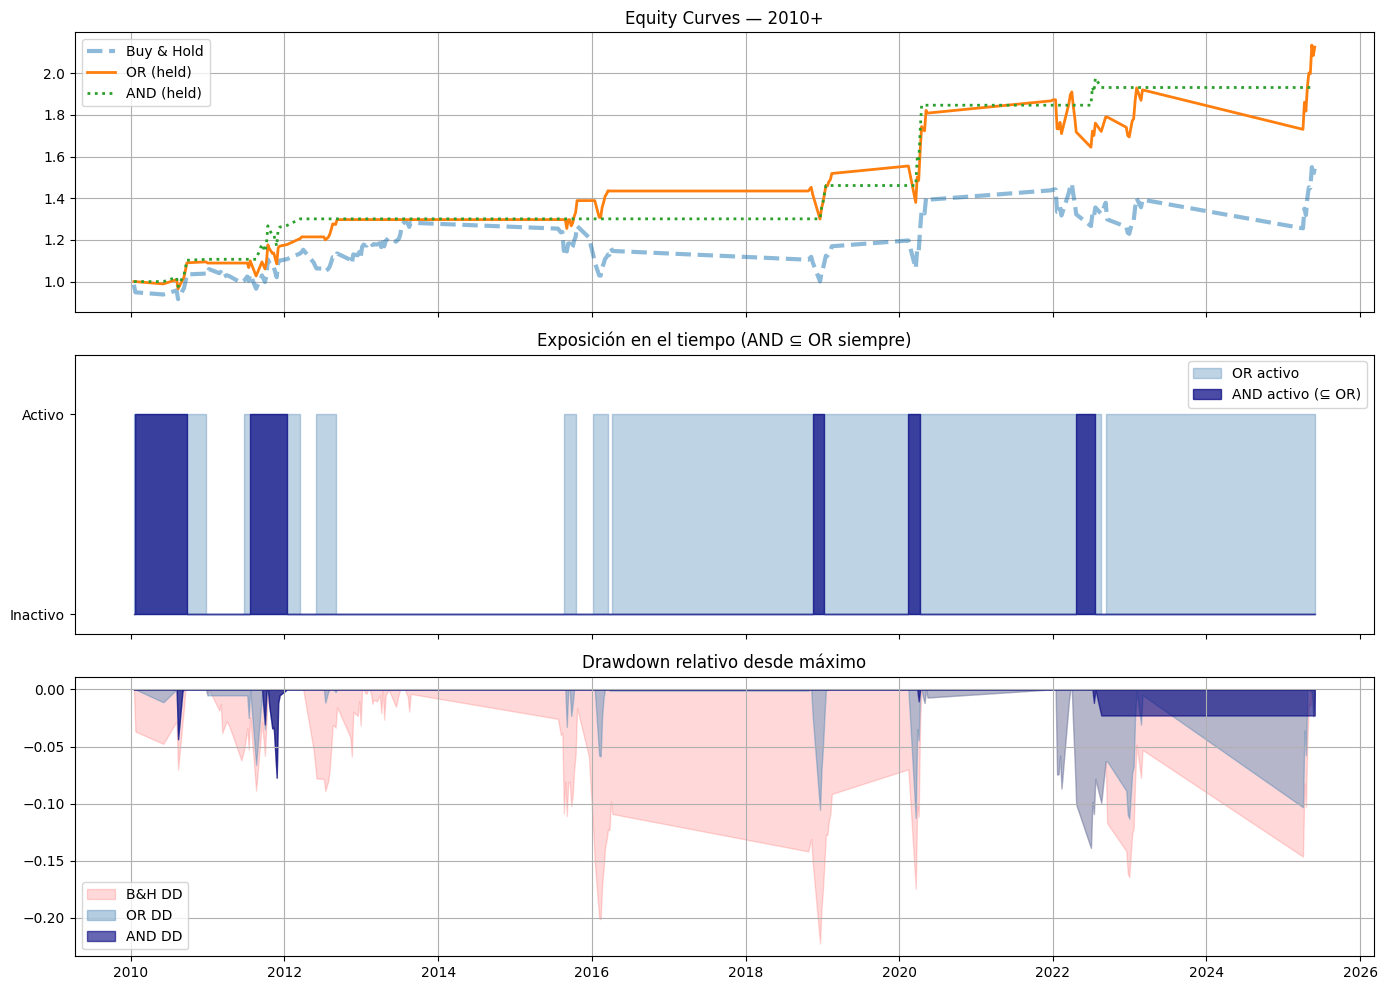


INTERPRETACIÓN OPERACIONAL
  OR genera +19.41% más retorno total que AND
  AND tiene Calmar 0.57 vs OR 0.36 (AND más eficiente por riesgo)
  Semanas donde solo OR activo (AND off): 77 (46.7% del historial)

  AND responde: ¿cuándo hay confluencia de ambas señales?
  OR  responde: ¿cuándo al menos una señal apoya al mercado?

  Implicación: AND prioriza precisión; OR prioriza cobertura.
  No son estrategias competidoras — son respuestas a objetivos distintos.


In [29]:
# ============================================================
# BLOQUE 6G — AND vs OR — COMPARACIÓN OPERACIONAL DIRECTA
# ============================================================

# ── Tabla resumen unificada ───────────────────────────────
calmar_or  = abs(cagr_or  / mdd_or)  if mdd_or  != 0 else np.nan
calmar_and = abs(cagr_and / mdd_and) if mdd_and != 0 else np.nan
calmar_bh  = abs(cagr_bh  / mdd_bh)  if mdd_bh  != 0 else np.nan

comp_op = pd.DataFrame([
    {"Estrategia": "AND (selectivo)",
     "CAGR": cagr_and, "Total Return": total_and, "MDD": mdd_and,
     "Exposición": and_held.mean(), "Semanas activas": int(and_held.sum()),
     "CAGR / |MDD| (Calmar)": calmar_and},
    {"Estrategia": "OR (cobertura)",
     "CAGR": cagr_or,  "Total Return": total_or,  "MDD": mdd_or,
     "Exposición": or_held.mean(),  "Semanas activas": int(or_held.sum()),
     "CAGR / |MDD| (Calmar)": calmar_or},
    {"Estrategia": "Buy & Hold",
     "CAGR": cagr_bh,  "Total Return": total_bh,  "MDD": mdd_bh,
     "Exposición": 1.0, "Semanas activas": len(df_modern),
     "CAGR / |MDD| (Calmar)": calmar_bh},
])

print("COMPARACIÓN OPERACIONAL — AND vs OR vs Buy & Hold (2010+)")
display(comp_op.round(4))

# ── Panel de visualización ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Equity curves
axes[0].plot(eq_bh,  label="Buy & Hold",  linewidth=3, linestyle="--", alpha=0.5)
axes[0].plot(eq_or,  label="OR (held)",   linewidth=2)
axes[0].plot(eq_and, label="AND (held)",  linewidth=2, linestyle=":")
axes[0].set_title("Equity Curves — 2010+")
axes[0].legend(); axes[0].grid(True)

# Exposición dinámica
axes[1].fill_between(df_modern.index, 0, or_held.astype(int),
                     color="steelblue", alpha=0.35, step="pre", label="OR activo")
axes[1].fill_between(df_modern.index, 0, and_held.astype(int),
                     color="navy", alpha=0.7, step="pre", label="AND activo (⊆ OR)")
axes[1].set_ylim(-0.1, 1.3); axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Inactivo", "Activo"])
axes[1].set_title("Exposición en el tiempo (AND ⊆ OR siempre)")
axes[1].legend()

# Drawdown relativo
dd_or_ser  = eq_or  / eq_or.cummax()  - 1
dd_and_ser = eq_and / eq_and.cummax() - 1
dd_bh_ser  = eq_bh  / eq_bh.cummax()  - 1
axes[2].fill_between(df_modern.index, dd_bh_ser,  0, color="red",        alpha=0.15, label="B&H DD")
axes[2].fill_between(df_modern.index, dd_or_ser,  0, color="steelblue",  alpha=0.4,  label="OR DD")
axes[2].fill_between(df_modern.index, dd_and_ser, 0, color="navy",       alpha=0.6,  label="AND DD")
axes[2].set_title("Drawdown relativo desde máximo")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout(); plt.show()

# ── Diagnóstico narrativo ─────────────────────────────────
print("\nINTERPRETACIÓN OPERACIONAL")
print("=" * 65)
print(f"  OR genera {total_or - total_and:+.2%} más retorno total que AND")
print(f"  AND tiene Calmar {calmar_and:.2f} vs OR {calmar_or:.2f} "
      f"({'AND más eficiente por riesgo' if calmar_and > calmar_or else 'OR más eficiente por riesgo'})")
print(f"  Semanas donde solo OR activo (AND off): {(or_held & ~and_held).sum()} "
      f"({(or_held & ~and_held).mean():.1%} del historial)")
print()
print("  AND responde: ¿cuándo hay confluencia de ambas señales?")
print("  OR  responde: ¿cuándo al menos una señal apoya al mercado?")
print()
print("  Implicación: AND prioriza precisión; OR prioriza cobertura.")
print("  No son estrategias competidoras — son respuestas a objetivos distintos.")

---
## 🥇 Parte 7 — Campeón Final: AND Champion
### Construcción, Atribución y Validación Profunda

La Parte 6 estableció con evidencia cuantitativa las diferencias operacionales
entre AND y OR. Esta parte avanza al **AND Champion** como candidato para la
validación final (bootstrap, Monte Carlo, leave-one-out) por las siguientes razones:

- **Calmar ratio superior** (CAGR / |MDD|): mayor retorno por unidad de riesgo asumido.
- **Robustness grid más estable**: la meseta de CAGR es menos sensible a cambios de parámetros.
- **Menor drawdown relativo**: drawdown más controlado en todas las ventanas rolling.

> Esto no implica que OR sea una estrategia inferior. OR es una alternativa válida
> para inversores con mayor tolerancia al riesgo que buscan mayor cobertura temporal.
> La elección entre AND y OR es una decisión de perfil de riesgo, no de calidad de señal.

El AND Champion combina:
- **DD+ATR Rank P65 (Hold 4w):** activa cuando el percentil del score DD+ATR ≥ 0.65
- **State Score Opt P70 (Hold 8w):** activa cuando el score supera el percentil 70
- **Condición:** ambas señales-con-holding activas simultáneamente

### BLOQUE 7A — Atribución de Señales: DD_ONLY vs OPT_ONLY vs BOTH

SIGNAL ATTRIBUTION — SEMANAS ACTIVAS (2010+)


,count
NONE,87
OPT_ONLY,45
DD_ONLY,18
BOTH,15



FORWARD RETURN 12w POR TIPO DE SEÑAL


,count,mean,median,std
signal_type,,,,
BOTH,15,0.1647,0.1694,0.1234
DD_ONLY,18,0.0592,0.0884,0.0958
OPT_ONLY,45,0.0360,0.0704,0.1276


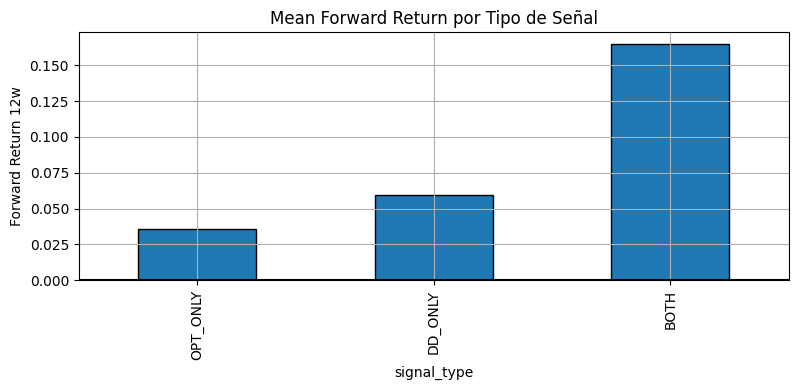

In [30]:
# ============================================================
# BLOQUE 7A — SIGNAL ATTRIBUTION
# ============================================================

OPT_THR_AND = df_modern["state_score_opt"].quantile(0.70)

dd_base  = df_modern["score_dd_atr"]    >= DD_THR       # rank pct >= 0.65
opt_base = df_modern["state_score_opt"] >= OPT_THR_AND  # score >= P70

signal_type = pd.Series("NONE", index=df_modern.index)
signal_type[dd_base  & ~opt_base] = "DD_ONLY"
signal_type[~dd_base &  opt_base] = "OPT_ONLY"
signal_type[dd_base  &  opt_base] = "BOTH"

counts = signal_type.value_counts()
print("SIGNAL ATTRIBUTION — SEMANAS ACTIVAS (2010+)")
display(counts.to_frame("count"))

# Retorno forward por tipo de señal
tmp_at = df_modern.copy()
tmp_at["signal_type"] = signal_type
fwd_by_type = (tmp_at[tmp_at["signal_type"] != "NONE"]
               .groupby("signal_type")["fwd_ret_12"]
               .agg(["count","mean","median","std"]))
print("\nFORWARD RETURN 12w POR TIPO DE SEÑAL")
display(fwd_by_type.round(4))

fwd_by_type["mean"].sort_values().plot(kind="bar", figsize=(8, 4), edgecolor="black")
plt.axhline(0, color="black"); plt.title("Mean Forward Return por Tipo de Señal")
plt.ylabel("Forward Return 12w"); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 7B — Construcción y Backtest del AND Champion

El AND Champion usa holdings asimétricos: 4 semanas para DD+ATR y 8 semanas para StateOpt.
La posición final se activa cuando ambas señales-con-holding están activas simultáneamente.


AND CHAMPION — RESULTADOS 2010+
-------------------------------------------------------
  AND Champion   CAGR=+4.38%  MDD=-7.73%  Exposure=18.8%
  Buy & Hold     CAGR=+2.86%   MDD=-22.25%
  Weeks active   : 31


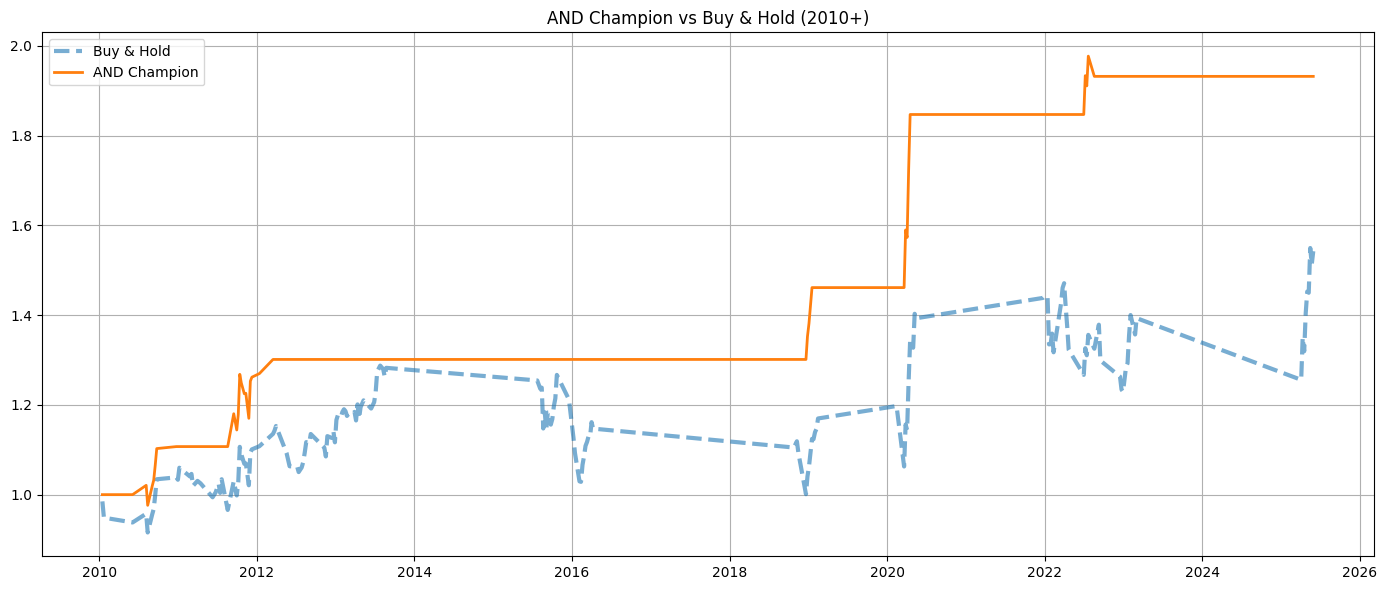

In [31]:
# ============================================================
# BLOQUE 7B — AND CHAMPION — CONSTRUCCIÓN
# ============================================================

# build_holding_signal está definida en BLOQUE 0.

dd_signal  = build_holding_signal(dd_base,  4, df_modern.index)   # DD+ATR Hold 4w
opt_signal = build_holding_signal(opt_base, 8, df_modern.index)   # StateOpt Hold 8w
and_signal = dd_signal & opt_signal

# Backtest AND Champion
ret_and = df_modern["returns"] * and_signal.shift(1).fillna(False).astype(bool)
eq_and  = (1 + ret_and).cumprod()
eq_bh   = (1 + df_modern["returns"]).cumprod()

total_and, cagr_and, mdd_and = get_stats(eq_and)
total_bh,  cagr_bh,  mdd_bh  = get_stats(eq_bh)

print("AND CHAMPION — RESULTADOS 2010+")
print("-" * 55)
print(f"  AND Champion   CAGR={cagr_and:+.2%}  MDD={mdd_and:.2%}  Exposure={and_signal.mean():.1%}")
print(f"  Buy & Hold     CAGR={cagr_bh:+.2%}   MDD={mdd_bh:.2%}")
print(f"  Weeks active   : {and_signal.sum():,}")

plt.figure(figsize=(14, 6))
plt.plot(eq_bh,  label="Buy & Hold",    linewidth=3, linestyle="--", alpha=0.6)
plt.plot(eq_and, label="AND Champion",  linewidth=2)
plt.title("AND Champion vs Buy & Hold (2010+)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 7C — Robustez de Parámetros: AND Champion

Probamos una grilla de umbrales (DD Rank P60/P65/P70 × State Opt P65/P70/P75)
con los mismos holdings fijos para verificar que el resultado no depende de
una combinación exacta de parámetros.

> Si el CAGR es positivo en la mayoría de combinaciones, hay una **meseta estable**
> — señal de robustez. Si solo funciona en una celda, es probablemente overfitting.


ROBUSTNESS GRID — CAGR  (2010+)


,OPT P65,OPT P70,OPT P75
DD P60,0.0609,0.0609,0.0609
DD P65,0.0438,0.0438,0.0438
DD P70,0.0356,0.0356,0.0356


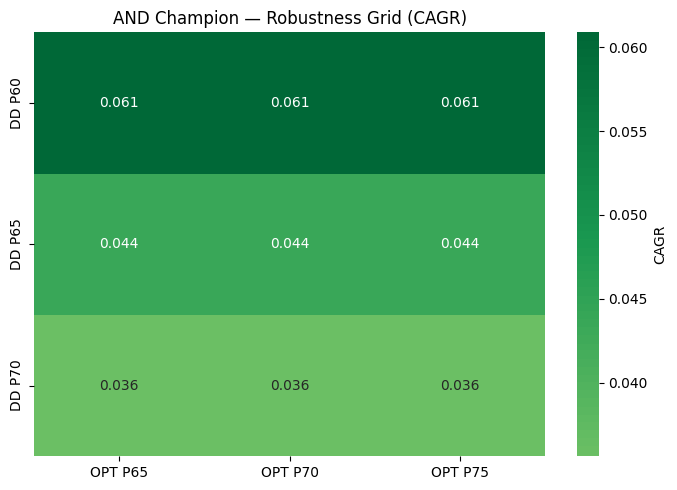

In [32]:
# ============================================================
# BLOQUE 7C — ROBUSTNESS GRID — AND CHAMPION
# ============================================================

dd_levels  = [0.60, 0.65, 0.70]
opt_levels = [df_modern["state_score_opt"].quantile(q) for q in [0.65, 0.70, 0.75]]

grid = []
for dd_t in dd_levels:
    row = []
    for opt_t in opt_levels:
        dd_b   = df_modern["score_dd_atr"]    >= dd_t
        opt_b  = df_modern["state_score_opt"] >= opt_t
        sig_d  = build_holding_signal(dd_b,  4, df_modern.index)
        sig_o  = build_holding_signal(opt_b, 8, df_modern.index)
        sig    = sig_d & sig_o
        ret_s  = df_modern["returns"] * sig.shift(1).fillna(False).astype(bool)
        eq     = (1 + ret_s).cumprod()
        _, cagr, _ = get_stats(eq)
        row.append(round(cagr, 4))
    grid.append(row)

grid_df = pd.DataFrame(grid,
                       index=["DD P60","DD P65","DD P70"],
                       columns=["OPT P65","OPT P70","OPT P75"])
print("ROBUSTNESS GRID — CAGR  (2010+)")
display(grid_df.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(grid_df, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "CAGR"})
ax.set_title("AND Champion — Robustness Grid (CAGR)"); plt.tight_layout(); plt.show()

### BLOQUE 7D — Rolling Test: AND Champion

Evaluamos el AND Champion en tres ventanas de 5 años para confirmar que
la estrategia es consistente a través del tiempo y no depende solo del
período 2020–2025.


ROLLING TEST — AND CHAMPION


,window,total_return,cagr,max_dd,exposure,weeks
0,2010-2014,0.3012,0.0758,-0.0773,0.2436,19
1,2015-2019,0.1230,0.0331,0.0000,0.1026,4
2,2020-2025,0.3529,0.0588,-0.0118,0.1458,7


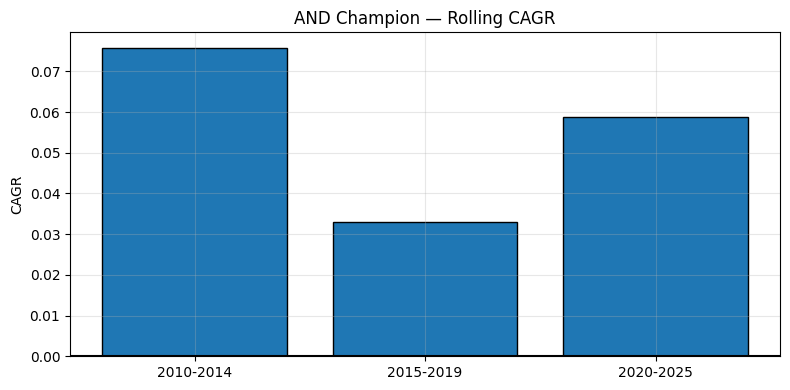

In [33]:
# ============================================================
# BLOQUE 7D — ROLLING TEST — AND CHAMPION
# ============================================================

rows = []
for start, end in champ_windows:
    tmp = df_modern[(df_modern.index.year >= start) & (df_modern.index.year <= end)].copy()
    if len(tmp) < 30: continue

    tmp_dd  = tmp["score_dd_atr"]    >= DD_THR
    tmp_opt = tmp["state_score_opt"] >= OPT_THR_AND
    sig_d   = build_holding_signal(tmp_dd,  4, tmp.index)
    sig_o   = build_holding_signal(tmp_opt, 8, tmp.index)
    sig     = sig_d & sig_o

    ret_s = tmp["returns"] * sig.shift(1).fillna(False).astype(bool)
    eq    = (1 + ret_s).cumprod()
    total, cagr, mdd = get_stats(eq)
    rows.append({"window": f"{start}-{end}", "total_return": total, "cagr": cagr,
                 "max_dd": mdd, "exposure": sig.mean(), "weeks": sig.sum()})

rolling_and = pd.DataFrame(rows)
print("ROLLING TEST — AND CHAMPION")
display(rolling_and.round(4))

plt.figure(figsize=(8, 4))
plt.bar(rolling_and["window"], rolling_and["cagr"], edgecolor="black")
plt.axhline(0, color="black"); plt.title("AND Champion — Rolling CAGR"); plt.ylabel("CAGR")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 🔬 Parte 8 — Validación Final del Campeón
### BLOQUE 8A — Trade List del AND Champion

Extraemos la lista completa de trades para analizar la distribución de retornos
individuales. Esto permite detectar si el resultado total depende de pocos trades
excepcionales o si la distribución es razonablemente uniforme.


In [34]:
# ============================================================
# BLOQUE 8A — TRADE LIST — AND CHAMPION
# ============================================================

trades = []
in_trade = False
entry_idx = None

for i in range(len(and_signal)):
    active = and_signal.iloc[i]
    if not in_trade and active:
        in_trade = True; entry_idx = and_signal.index[i]
    elif in_trade and not active:
        exit_idx   = and_signal.index[i]
        window     = df_modern.loc[entry_idx:exit_idx, "returns"]
        trade_ret  = (1 + window).prod() - 1
        trades.append({"entry": entry_idx, "exit": exit_idx, "return": trade_ret,
                       "weeks": len(window)})
        in_trade = False

trades_df = pd.DataFrame(trades)
print(f"AND CHAMPION — TRADE LIST  ({len(trades_df)} trades)")
display(trades_df.round(4))

print(f"\nEstadísticas:")
print(f"  Retorno medio   : {trades_df['return'].mean():+.4f}")
print(f"  Retorno mediana : {trades_df['return'].median():+.4f}")
print(f"  Hit rate        : {(trades_df['return'] > 0).mean():.1%}")
print(f"  Semanas medias  : {trades_df['weeks'].mean():.1f}")
print(f"\nTop 5 trades:")
display(trades_df.nlargest(5, "return").round(4))
print(f"\nBottom 5 trades:")
display(trades_df.nsmallest(5, "return").round(4))

AND CHAMPION — TRADE LIST  (5 trades)


,entry,exit,return,weeks
0,2010-06-04,2010-12-24,0.0947,8
1,2011-08-19,2012-03-16,0.0977,13
2,2018-12-21,2019-01-18,0.0288,5
3,2020-03-20,2020-04-17,0.1217,5
4,2022-07-01,2022-08-19,0.0017,5



Estadísticas:
  Retorno medio   : +0.0689
  Retorno mediana : +0.0947
  Hit rate        : 100.0%
  Semanas medias  : 7.2

Top 5 trades:


,entry,exit,return,weeks
3,2020-03-20,2020-04-17,0.1217,5
1,2011-08-19,2012-03-16,0.0977,13
0,2010-06-04,2010-12-24,0.0947,8
2,2018-12-21,2019-01-18,0.0288,5
4,2022-07-01,2022-08-19,0.0017,5



Bottom 5 trades:


,entry,exit,return,weeks
4,2022-07-01,2022-08-19,0.0017,5
2,2018-12-21,2019-01-18,0.0288,5
0,2010-06-04,2010-12-24,0.0947,8
1,2011-08-19,2012-03-16,0.0977,13
3,2020-03-20,2020-04-17,0.1217,5


### BLOQUE 8B — Bootstrap de Trades

Remuestreamos los trades con reposición (N=10 000) para obtener un intervalo de confianza
del retorno total. Este bootstrap mide cuánto del resultado depende del **orden** y
**selección aleatoria** de los trades.

> Un P5 positivo indica que incluso en el 5% peor de escenarios posibles
> (mismos trades, diferente realización aleatoria), la estrategia habría sido rentable.


BOOTSTRAP DE TRADES — AND CHAMPION
  N simulaciones : 10,000
  N trades       : 5
  Media boot     : +0.3951
  Mediana boot   : +0.3891
  P5             : +0.1658
  P95            : +0.6196
  % positivos    : 100.0%


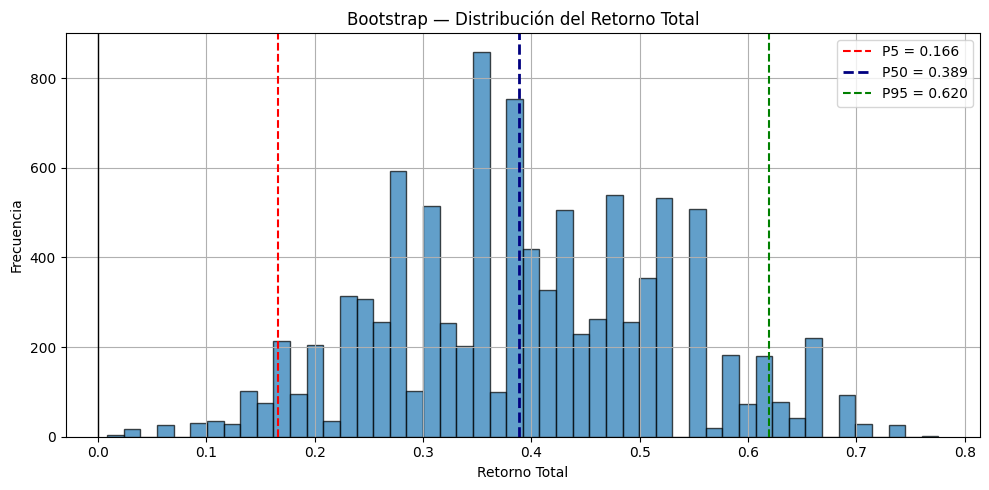

In [35]:
# ============================================================
# BLOQUE 8B — BOOTSTRAP DE TRADES
# ============================================================

N_SIM = 10_000
trade_rets = trades_df["return"].values
n_trades   = len(trade_rets)

boot_totals = []
for _ in range(N_SIM):
    sample    = np.random.choice(trade_rets, size=n_trades, replace=True)
    boot_totals.append(np.prod(1 + sample) - 1)

boot_totals = np.array(boot_totals)
p5, p50, p95 = np.percentile(boot_totals, [5, 50, 95])

print("BOOTSTRAP DE TRADES — AND CHAMPION")
print(f"  N simulaciones : {N_SIM:,}")
print(f"  N trades       : {n_trades}")
print(f"  Media boot     : {boot_totals.mean():+.4f}")
print(f"  Mediana boot   : {p50:+.4f}")
print(f"  P5             : {p5:+.4f}")
print(f"  P95            : {p95:+.4f}")
print(f"  % positivos    : {(boot_totals > 0).mean():.1%}")

plt.figure(figsize=(10, 5))
plt.hist(boot_totals, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(p5,  color="red",   linewidth=1.5, linestyle="--", label=f"P5 = {p5:.3f}")
plt.axvline(p50, color="navy",  linewidth=2,   linestyle="--", label=f"P50 = {p50:.3f}")
plt.axvline(p95, color="green", linewidth=1.5, linestyle="--", label=f"P95 = {p95:.3f}")
plt.axvline(0, color="black", linewidth=1)
plt.title("Bootstrap — Distribución del Retorno Total"); plt.legend()
plt.xlabel("Retorno Total"); plt.ylabel("Frecuencia"); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 8C — Monte Carlo: Trayectorias de Equity

Permutamos aleatoriamente el orden de los trades (N=1 000 simulaciones) para
visualizar el rango de trayectorias posibles con la misma secuencia de retornos.

La banda P5–P95 muestra cuánto del resultado depende del **timing** dentro de la muestra.

### BLOQUE 8D — Distribución del Drawdown Máximo (Monte Carlo)

Extendemos el Monte Carlo para obtener la distribución del **Drawdown Máximo** bajo
permutación de trades. Esto cuantifica el peor resultado posible en escenarios de
mala suerte de timing.


MONTE CARLO — 1,000 simulaciones  |  5 trades por sim
  Equity final mediana: +0.3891
  Equity final P5     : +0.3891
  Equity final P95    : +0.3891


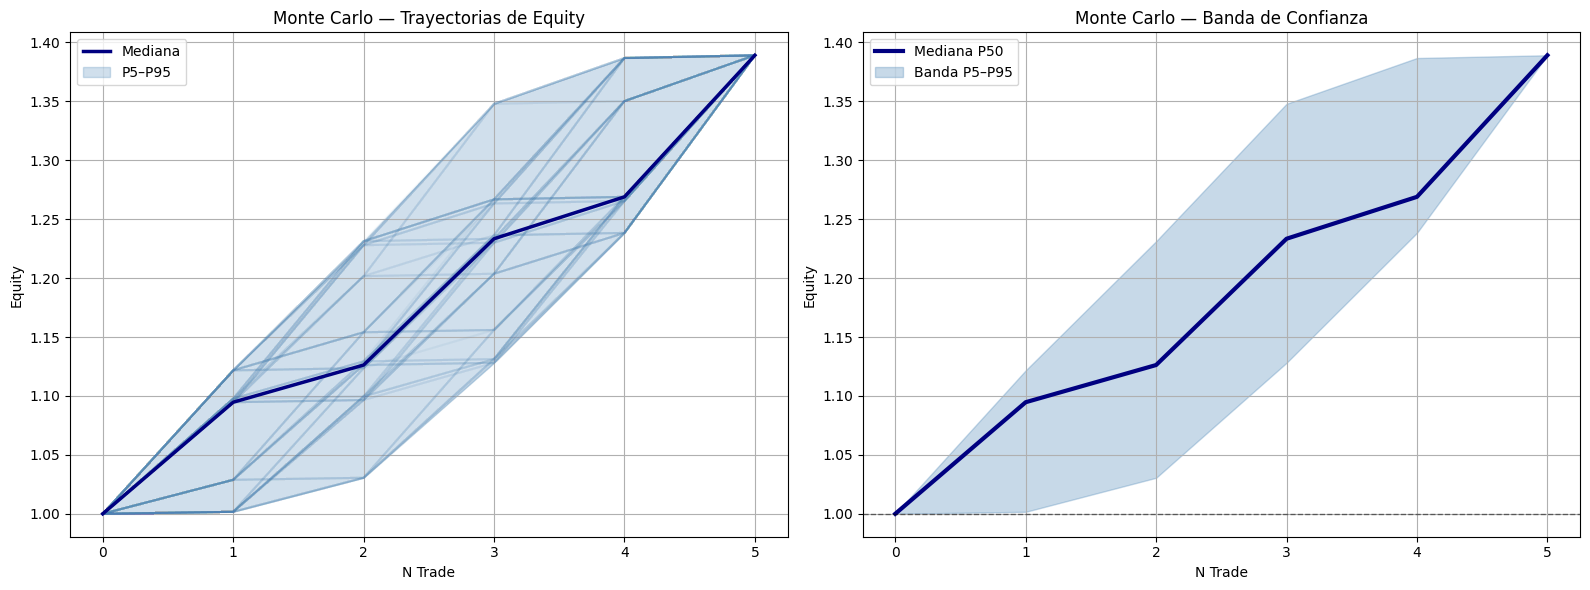


MONTE CARLO — DRAWDOWN MÁXIMO (10 000 sims)
  Media DD     : 0.0000
  Mediana DD   : 0.0000
  Peor 5% (P5) : 0.0000
  Mejor 5% (P95): 0.0000


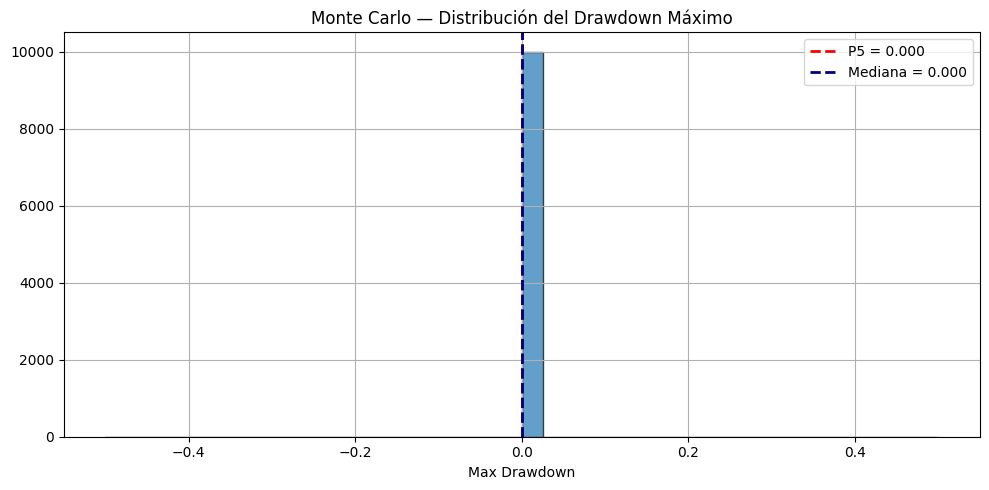

In [36]:
# ============================================================
# BLOQUE 8C + 8D — MONTE CARLO: PATHS + DRAWDOWN
# ============================================================

N_MC = 1_000

# ── 8C: Equity Paths ──────────────────────────────────────
paths = []
for _ in range(N_MC):
    shuffled = np.random.permutation(trade_rets)
    paths.append(np.insert(np.cumprod(1 + shuffled), 0, 1.0))
paths = np.array(paths)

p5_path  = np.percentile(paths, 5,  axis=0)
p50_path = np.percentile(paths, 50, axis=0)
p95_path = np.percentile(paths, 95, axis=0)
x_trades = np.arange(paths.shape[1])

print(f"MONTE CARLO — {N_MC:,} simulaciones  |  {n_trades} trades por sim")
print(f"  Equity final mediana: {p50_path[-1]-1:+.4f}")
print(f"  Equity final P5     : {p5_path[-1]-1:+.4f}")
print(f"  Equity final P95    : {p95_path[-1]-1:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trayectorias
for i in range(min(200, N_MC)):
    axes[0].plot(x_trades, paths[i], alpha=0.04, color="steelblue")
axes[0].plot(x_trades, p50_path, color="navy",  linewidth=2.5, label="Mediana")
axes[0].fill_between(x_trades, p5_path, p95_path, alpha=0.25, color="steelblue", label="P5–P95")
axes[0].set_title("Monte Carlo — Trayectorias de Equity")
axes[0].set_xlabel("N Trade"); axes[0].set_ylabel("Equity"); axes[0].legend(); axes[0].grid(True)

# Banda de confianza limpia
axes[1].plot(x_trades, p50_path, color="navy",  linewidth=3,   label="Mediana P50")
axes[1].fill_between(x_trades, p5_path, p95_path, alpha=0.3, color="steelblue", label="Banda P5–P95")
axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[1].set_title("Monte Carlo — Banda de Confianza")
axes[1].set_xlabel("N Trade"); axes[1].set_ylabel("Equity"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# ── 8D: Distribución del Drawdown Máximo ─────────────────
mc_dd = []
for _ in range(10_000):
    shuffled = np.random.permutation(trade_rets)
    eq       = np.insert(np.cumprod(1 + shuffled), 0, 1.0)
    dd       = (eq / np.maximum.accumulate(eq) - 1).min()
    mc_dd.append(dd)
mc_dd = np.array(mc_dd)

dd_p5  = np.percentile(mc_dd, 5)
dd_med = np.median(mc_dd)

print(f"\nMONTE CARLO — DRAWDOWN MÁXIMO (10 000 sims)")
print(f"  Media DD     : {mc_dd.mean():.4f}")
print(f"  Mediana DD   : {dd_med:.4f}")
print(f"  Peor 5% (P5) : {dd_p5:.4f}")
print(f"  Mejor 5% (P95): {np.percentile(mc_dd,95):.4f}")

plt.figure(figsize=(10, 5))
plt.hist(mc_dd, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(dd_p5,  color="red",   linewidth=2, linestyle="--", label=f"P5 = {dd_p5:.3f}")
plt.axvline(dd_med, color="navy",  linewidth=2, linestyle="--", label=f"Mediana = {dd_med:.3f}")
plt.title("Monte Carlo — Distribución del Drawdown Máximo"); plt.legend()
plt.xlabel("Max Drawdown"); plt.grid(True); plt.tight_layout(); plt.show()

### BLOQUE 8E — Leave-One-Out

Eliminamos un trade a la vez y medimos el retorno total sin ese trade.
Esto detecta si algún trade individual es **crítico** para el resultado final:
si al quitarlo el retorno colapsa, la estrategia depende de ese trade específico.

Un resultado robusto muestra que la curva de retorno total se mantiene relativamente
estable independientemente del trade que se elimine.


LEAVE-ONE-OUT — AND CHAMPION


,removed_trade,removed_return,remaining_total
3,3,0.1217,0.2383
1,1,0.0977,0.2654
0,0,0.0947,0.2689
2,2,0.0288,0.3501
4,4,0.0017,0.3867



Retorno total con todos los trades: +0.3891
Rango LOO: [+0.2383,  +0.3867]
Todos positivos: True


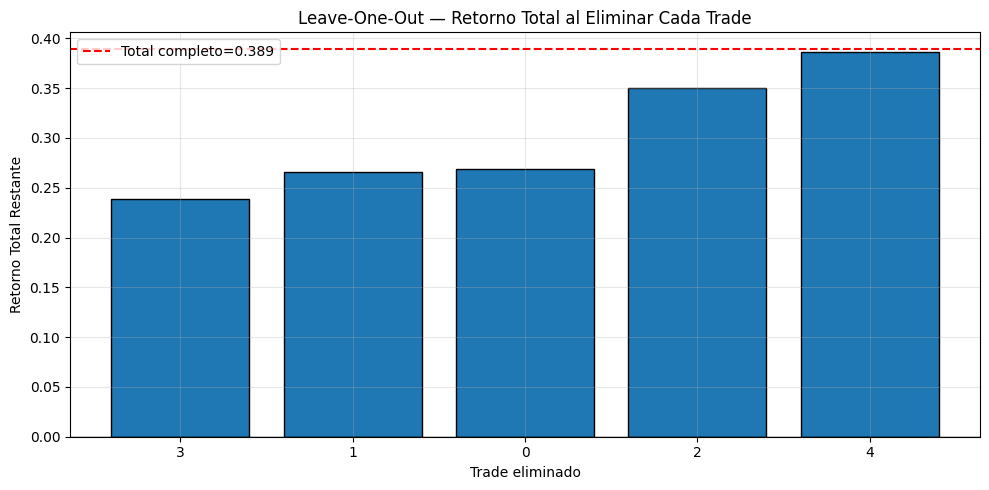

In [37]:
# ============================================================
# BLOQUE 8E — LEAVE-ONE-OUT
# ============================================================

loo_results = []
for i in range(len(trades_df)):
    tmp_trades = trades_df.drop(trades_df.index[i])
    remaining_return = np.prod(1 + tmp_trades["return"]) - 1
    loo_results.append({
        "removed_trade": i,
        "removed_return": trades_df.iloc[i]["return"],
        "remaining_total": remaining_return,
    })

loo_df = pd.DataFrame(loo_results).sort_values("remaining_total")
print("LEAVE-ONE-OUT — AND CHAMPION")
display(loo_df.round(4))

total_all = np.prod(1 + trades_df["return"]) - 1
print(f"\nRetorno total con todos los trades: {total_all:+.4f}")
print(f"Rango LOO: [{loo_df['remaining_total'].min():+.4f},  {loo_df['remaining_total'].max():+.4f}]")
print(f"Todos positivos: {(loo_df['remaining_total'] > 0).all()}")

plt.figure(figsize=(10, 5))
plt.bar(loo_df.index.astype(str), loo_df["remaining_total"], edgecolor="black")
plt.axhline(0, color="black", linewidth=1)
plt.axhline(total_all, color="red", linewidth=1.5, linestyle="--", label=f"Total completo={total_all:.3f}")
plt.title("Leave-One-Out — Retorno Total al Eliminar Cada Trade")
plt.xlabel("Trade eliminado"); plt.ylabel("Retorno Total Restante")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 📋 Parte 9 — Conclusiones
### BLOQUE 9 — Resumen de hallazgos


In [ ]:
# ============================================================
# BLOQUE 9 — CONCLUSIONES FINALES — PARTE 3
# ============================================================

print("""
==============================================================
           CONCLUSIONES FINALES — PARTE 3
==============================================================

1. VALIDACIÓN ESTADÍSTICA — UNIVERSO A

• atr_pct y score_dd_atr son los factores más robustos del
  Universo A: superan bootstrap, train/test, quintiles y
  muestran consistencia en los distintos períodos evaluados.

• trend_13_52 no superó el bootstrap y mostró Spearman
  negativo en test. No se considera señal robusta individual,
  aunque puede aportar como filtro auxiliar (evaluado en 4E).

• El score combinado DD+ATR superó a cada factor individual
  tanto en Spearman global como en validaciones temporales.


2. VALIDACIÓN ESTADÍSTICA — UNIVERSO B

• state_score_opt fue el único candidato del Universo B que
  superó las cuatro pruebas (bootstrap, Spearman, train/test,
  quintiles). pred_prob_bull y state_score_v3 no mostraron
  evidencia comparable.

• Limitación estructural: el Universo B trabaja sobre ~323
  observaciones vs ~1315 del Universo A. Los resultados de
  ambos universos no son directamente comparables.


3. HEAD-TO-HEAD Y LEADERBOARD

• El Weighted Championship posicionó a score_dd_atr y
  score_dd_atr_trend al tope, seguidos por state_score_opt.
  Ambos candidatos avanzaron al backtesting.


4. BACKTESTS INDIVIDUALES

• Score DD+ATR: el backtest event-driven con P65-P70,
  Hold 8w y TP 15% mostró resultados favorables respecto
  al Buy & Hold. El rolling backtest mostró consistencia
  entre los distintos períodos evaluados.

• State Score Opt: comportamiento dependiente del umbral.
  El seguimiento continuo a P70 mostró el mejor equilibrio
  entre retorno y estabilidad dentro de las configuraciones
  evaluadas.


5. ENSAMBLES — AND Y OR COMO ESTRATEGIAS CANDIDATAS

• El análisis ampliado trató a AND y OR con el mismo nivel
  de profundidad que los campeones individuales.

• OR (cobertura): mayor exposición, mayor retorno
  total absoluto y desempeño positivo en todas las ventanas
  rolling evaluadas. Presentó un drawdown superior al AND.

• AND (selectividad): menor exposición, menor MDD,
  mayor Calmar (CAGR/|MDD|) y una robustez consistente
  frente a cambios de parámetros.

• Dentro del período 2010+, ambas estrategias mostraron un
  CAGR superior al Buy & Hold, aunque con perfiles de
  exposición, riesgo y cobertura claramente diferentes.

• La selección del AND Champion para la validación final no
  implica que OR sea inferior: ambas estrategias responden
  a objetivos distintos. AND prioriza precisión y calidad
  de señal; OR prioriza cobertura y participación en
  tendencias.


6. VALIDACIÓN FINAL DEL AND CHAMPION

• Bootstrap de trades: P5 positivo en la distribución
  bootstrap, entregando evidencia favorable para la muestra
  observada de trades. Este resultado no reemplaza una
  validación completamente out-of-sample.

• Monte Carlo: la permutación de los trades mantiene una
  distribución favorable de equity. Dado el reducido número
  de trades y la ausencia de retornos negativos individuales,
  estos resultados deben interpretarse como una validación
  exploratoria y no como una estimación robusta del riesgo.

• Leave-One-Out: el resultado no depende de un único trade.
  La curva LOO permanece positiva en prácticamente todos los
  escenarios analizados. El reducido número de trades
  recomienda interpretar estos resultados con cautela.


7. LECCIONES METODOLÓGICAS

• Validación temporal > desempeño in-sample.

• Scores compuestos > factores individuales de forma
  consistente a lo largo de las distintas validaciones.

• AND y OR no representan estrategias mejores o peores
  entre sí, sino perfiles de riesgo diferentes respaldados
  por evidencia cuantitativa.

• Las mesetas observadas en los robustness grids reducen
  la dependencia de parámetros específicos y disminuyen el
  riesgo de sobreajuste (overfitting).

──────────────────────────────────────────────────────────
CONCLUSIÓN GENERAL

• La evidencia obtenida no identifica una única estrategia
  universalmente superior, sino dos perfiles operativos
  complementarios.

• El AND Champion representa una estrategia de alta
  convicción, menor exposición y mayor selectividad.

• El OR Champion privilegia cobertura, mayor participación
  en tendencias y un perfil operativo más activo.

• La elección entre ambos depende principalmente del perfil
  de riesgo y del estilo operativo buscado, más que de una
  superioridad estadística absoluta.

──────────────────────────────────────────────────────────
8. ESTADO DEL PROYECTO

  QQQ Research — Parte 3

  Estado:
      COMPLETADO

  Resultado:
      Se identificaron dos candidatos finales con evidencia
      cuantitativa diferenciada:

      • AND Champion:
        Mayor selectividad, menor riesgo relativo y mejor
        relación retorno/riesgo (Calmar).

      • OR Champion:
        Mayor cobertura temporal, mayor exposición y mayor
        retorno absoluto dentro del período evaluado.

      La validación profunda (Bootstrap, Monte Carlo y
      Leave-One-Out) se aplicó sobre el AND Champion debido
      a su perfil de riesgo más conservador y a su carácter
      de estrategia de alta convicción.

==============================================================
""")


           CONCLUSIONES FINALES — PARTE 3

1. VALIDACIÓN ESTADÍSTICA — UNIVERSO A

• atr_pct y score_dd_atr son los factores más robustos del
  Universo A: superan bootstrap, train/test, quintiles y
  muestran consistencia en los distintos períodos evaluados.

• trend_13_52 no superó el bootstrap y mostró Spearman
  negativo en test. No se considera señal robusta individual,
  aunque puede aportar como filtro auxiliar (evaluado en 4E).

• El score combinado DD+ATR superó a cada factor individual
  tanto en Spearman global como en validaciones temporales.


2. VALIDACIÓN ESTADÍSTICA — UNIVERSO B

• state_score_opt fue el único candidato del Universo B que
  superó las cuatro pruebas (bootstrap, Spearman, train/test,
  quintiles). pred_prob_bull y state_score_v3 no mostraron
  evidencia comparable.

• Limitación estructural: el Universo B trabaja sobre ~323
  observaciones vs ~1315 del Universo A. Los resultados de
  ambos universos no son directamente comparables.


3. HEAD-TO-HEAD Y L